# Introduction

This code generates the figures for the paper "Interannual controls of the phytoplankton assemblages in Baffin Bay".

## Directory structure

binder, where is the .yml file for the conda virtual environment.

data, where are the observed winter nutrients from the Qikiqtarjuaq ice camps 2015 and 2016, the prescribed winter nutrients for the sensitivity experiments, the outputs of the model MITgcm and the observed winter nutrients for the 11 expeditions mentioned in Ardyna et al. (2020) in *Elem. Sci. Anth.*.

figures, where are the figures.

## Environment

This notebook was run in a conda virtual environment. The following commands will automatically create the environment and launch the Jupyter notebook:

```
cd <my_path>/assemblages
conda env create -f binder/environment_assemblages.yml
conda activate assemblages
jupyter notebook
```

Once the environment assemblages is created, the Jupyter notebook can be launched simply with:

```
cd <my_path>/assemblages
conda activate assemblages
jupyter notebook
```

# Code

## Load libraries

In [1]:
%matplotlib inline

import cycler
import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
import netcdf_tools
import numpy as np
import os
import pandas as pd
import plankpy
import re
import read_mitgcm

## Parameters for the figures

In [2]:
# dpi='figure' # default dpi
dpi=600
# ext='png'
ext='jpeg'

## Date of the simulations

The date when the the simulations were ran in the format yyyymmdd will be used to construct the names of the output files.

In [3]:
indir_outputs='data/DataS3_outputs_short'

In [4]:
pattern=\
'^groups\.run_(?P<yyyymmdd>\d{8})\w*_sims\.csv$'
regex=re.compile(pattern)
files=os.listdir(indir_outputs)
found=False
ifile=0
while(ifile<len(files) and not found):
    fname_example=files[ifile]
    match=regex.match(fname_example)
    if match!=None:
        found=True
        yyyymmdd=match.group('yyyymmdd')
    ifile=ifile+1
cwd=os.getcwd()
assert found, \
'current working directory %r contains no file with a name corresponding to %r' \
% (cwd,pattern)

In [5]:
fname_example

'groups.run_20240930_0000_EXP2_3no3_00_si_00_122_sims.csv'

In [6]:
yyyymmdd

'20240930'

## Grid

In [7]:
gridfile\
='data/DataS4_outputs_long/run_'\
+yyyymmdd\
+'_0000_EXP2_3si_standard_no3_standard_122_sims/grid.t001.nc'

drF is the r cell face separation, meaning the thickness of each depth layer (in m).

It corresponds to delR on https://mitgcm.readthedocs.io/en/latest/getting_started/getting_started.html#grid

In [8]:
drF=netcdf_tools.read_netcdf(gridfile,'drF')

RC is the r coordiante of cell center (in m).
We switch sign to have positive depths.

In [9]:
RC=-netcdf_tools.read_netcdf(gridfile,'RC')

RF is the r coordinate of cell interface (in m). We switch sign to have positive depths.

In [10]:
RF=-netcdf_tools.read_netcdf(gridfile,'RF')

In [11]:
RF_above151=RF[RF<151]

## Time duration

Each year had 365 days in the simulation and there was a spinup of 10 years.

In [12]:
nbyears=10
last_year=np.arange(365*(nbyears-1)+0,365*(nbyears-1)+365)
array1d_iT1y_iT=last_year

For the plots or for the mesh data of heatmaps 
(see https://matplotlib.org/stable/gallery/images_contours_and_fields/pcolormesh_grids.html#sphx-glr-gallery-images-contours-and-fields-pcolormesh-grids-py).

In [13]:
first_year=np.arange(0,365)
first_year_from_may1=np.arange(121,365)

For the meshgrid of heatmaps.

In [14]:
first_year366_from_may1=np.arange(121,366)

# Nitrate and silicate concentration profiles

In [15]:
infile_no3_standard\
='data/DataS1_winter_nutrients_in_situ_qik/1D_BB_NO3_GE_spring.delZ1016mm.32bits.bin'
infile_si_standard\
='data/DataS1_winter_nutrients_in_situ_qik/1D_BB_Si_GE_spring.delZ1016mm.32bits.bin'
no3_prefix\
='data/DataS2_winter_nutrients_simulated/1D_BB_NO3_GE_spring.delZ1016mm.32bits.'
si_prefix\
='data/DataS2_winter_nutrients_simulated/1D_BB_Si_GE_spring.delZ1016mm.32bits.'

In [16]:
array1d_idepth_no3_standard=np.fromfile(infile_no3_standard,
                                        dtype='>f')
array1d_idepth_si_standard=np.fromfile(infile_si_standard,
                                       dtype='>f')

Multiplying factors by which to multiply $NO_3$ at 100 m

In [17]:
no3_goals=np.arange(0,21,2)

Multiplying factors by which to multiply $\mathrm{ Si{(OH)}_4 }$ at 100 m

In [18]:
si_goals=np.arange(0,21,2)

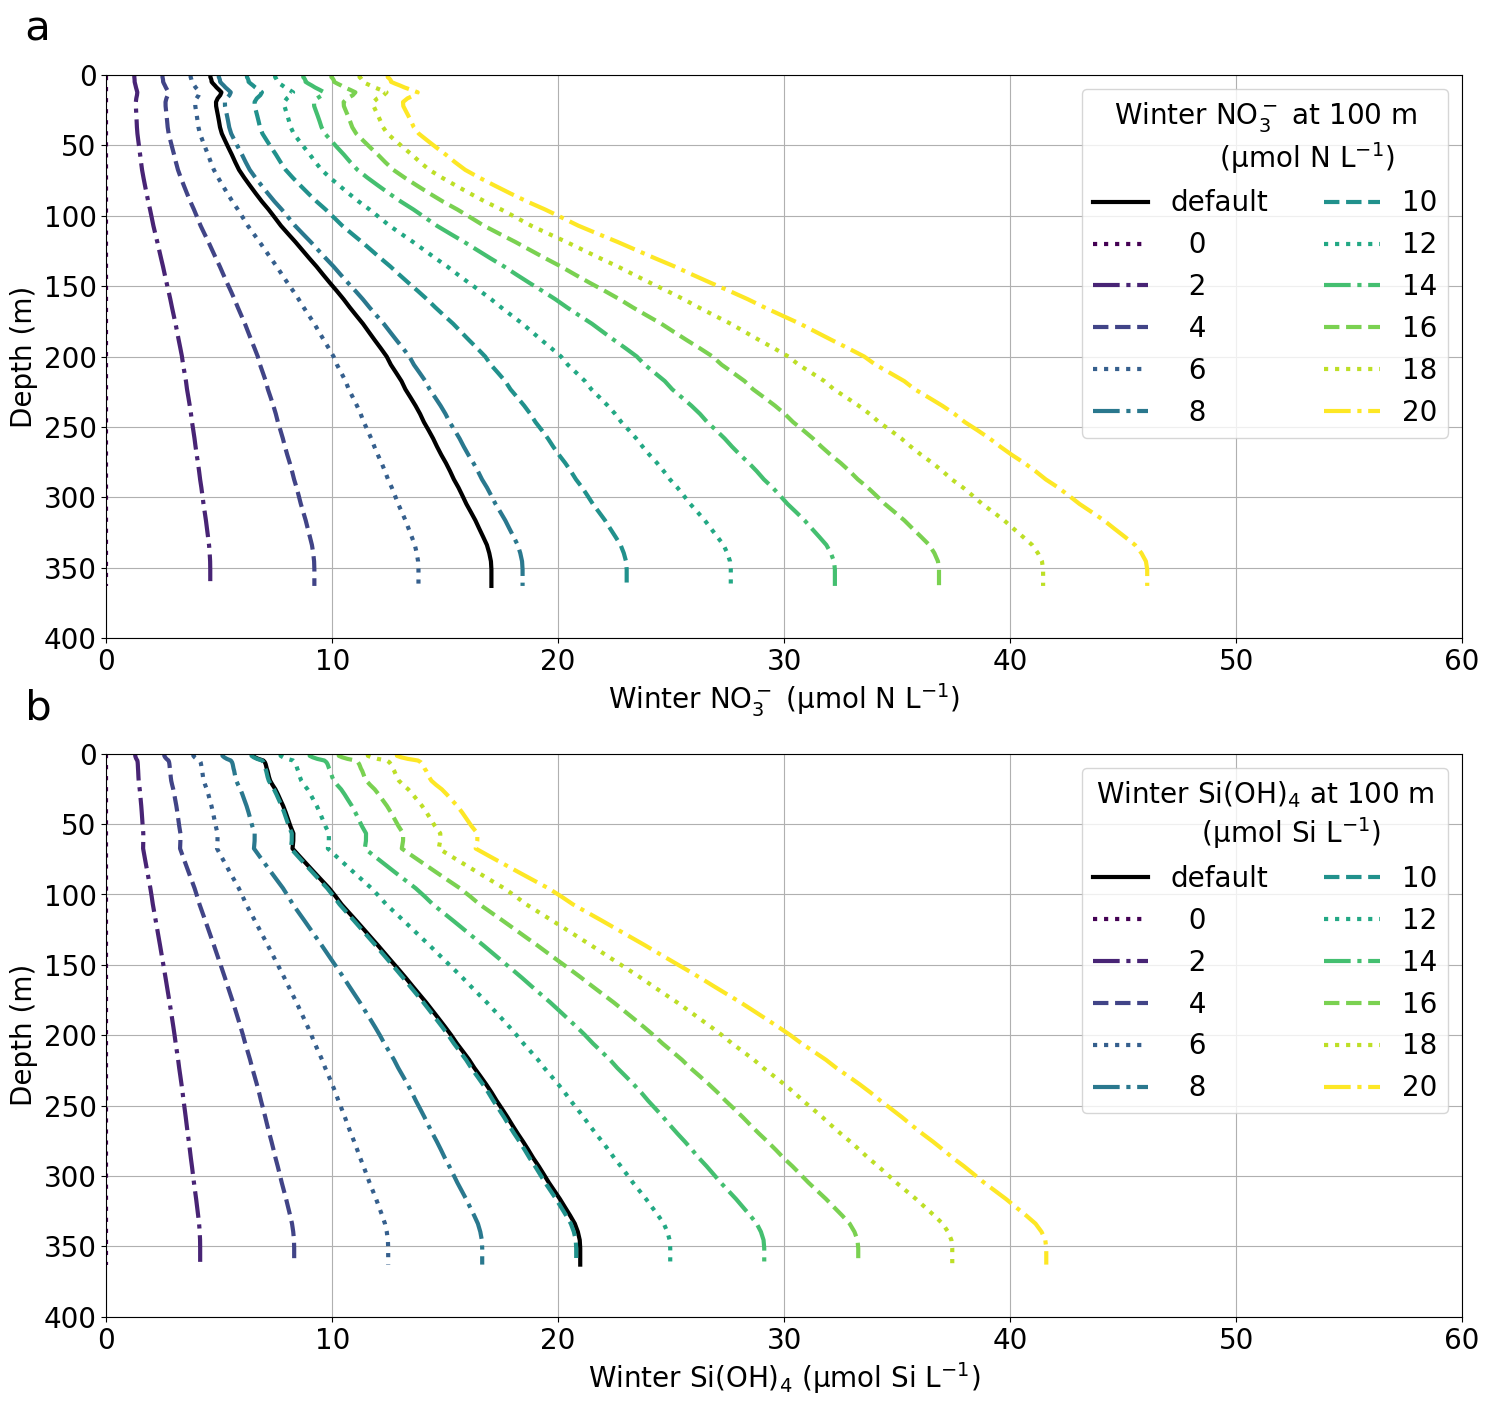

In [19]:
def make_plots(axs):
    box=dict(pad=5,alpha=0)
    
    # --- NITRATE
    ax=axs[0]
    # default
    ax.plot(array1d_idepth_no3_standard,RC,
            color='black',ls='-',label='default')
    ax.set_xlabel('Winter $\mathrm{ NO_3^-\ (\mu mol\ N\ L^{-1}) }$')
    ax.set_ylabel('Depth (m)')
    ax.set_xlim(0,60)
    ax.set_ylim(0,400)
    ax.invert_yaxis()
    ax.grid(True)
    plt.tight_layout()
    # sensitivity simulations
    cc=cycler.cycler(color=plt.cm.viridis(
        np.linspace(0,1,no3_goals.size)),
                     linestyle=[':','-.','--',':','-.','--',
                                ':','-.','--',':','-.'])
    ax.set_prop_cycle(cc)
    for no3_goal in no3_goals:
        label='{0:02}'.format(no3_goal)
        infile_no3=no3_prefix+label+'.bin'
        array1d_idepth_no3=np.fromfile(infile_no3,dtype='>f')
        label_nice=label
        if label.startswith('0'):
            label=label[1:]
            label_nice='  '+label
        ax.plot(array1d_idepth_no3,RC,label=label_nice)
    ax.legend(title='$\mathrm{ Winter\ NO_3^- }$ at 100 m\n            ($\mathrm{ \mu mol\ N\ L^{-1} }$)',
              ncol=2)
    plt.text(-0.05,1.08,' a ',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes, fontsize=30)
    
    # --- SILICATE
    ax=axs[1]
    # default
    ax.plot(array1d_idepth_si_standard,RC,
            color='black',ls='-',label='default')
    ax.set_xlabel('Winter $\mathrm{ Si(OH)_4\ (\mu mol\ Si\ L^{-1}) }$')
    ax.set_ylabel('Depth (m)')
    ax.set_xlim(0,60)
    ax.set_ylim(0,400)
    ax.invert_yaxis()
    ax.grid(True)
    plt.tight_layout()
    # sensitivity simulations
    cc=cycler.cycler(color=plt.cm.viridis(
        np.linspace(0,1,no3_goals.size)),
                     linestyle=[':','-.','--',':','-.','--',
                                ':','-.','--',':','-.'])
    ax.set_prop_cycle(cc)
    for si_goal in si_goals:
        label='{0:02}'.format(si_goal)
        infile_si=si_prefix+label+'.bin'
        array1d_idepth_si=np.fromfile(infile_si,dtype='>f')
        label_nice=label
        if label.startswith('0'):
            label=label[1:]
            label_nice='  '+label
        ax.plot(array1d_idepth_si,RC,label=label_nice)
    ax.legend(title='$\mathrm{ Winter\ Si(OH)_4 }$ at 100 m\n            ($\mathrm{ \mu mol\ Si\ L^{-1} }$)',
              ncol=2)
    plt.text(-0.05,1.08,' b ',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes, fontsize=30)
    
    # --- POSITION
    axs[0].set_position( [0.07,0.55  ,0.91,0.39])
    axs[1].set_position( [0.07,0.08  ,0.91,0.39])
    
with plt.style.context('mplstyles/data_rbcs.mplstyle'):
    # Plot
    fig,axs=plt.subplots(2,1,figsize=(14.90,14.44))
    make_plots(axs)

    # --- SAVE
    outfile='figures/figure1.'+ext
    plt.savefig(outfile,dpi=dpi)

# Heatmaps for different winter nutrient concentrations

Read reference nitrate at 100 m (in $\mathrm{ \mu mol\ L^{-1} }$).

In [20]:
x=100
xp=[RC[28],RC[29]] # Between 95.5528315 m and 101.2971055 m
assert np.all(np.diff(xp)>0), \
"xp is in decreasing order: %r %r" % (xp[0],xp[1])
fp=[array1d_idepth_no3_standard[28],array1d_idepth_no3_standard[29]]
no3_standard_100m=np.interp(x,xp,fp)

Read reference silicate at 100 m (in $\mathrm{ \mu mol\ L^{-1} }$).

In [21]:
array1d_idepth_si_standard=np.fromfile(infile_si_standard,dtype='>f')
x=100
xp=[RC[28],RC[29]] # Between 95.5528315 m and 101.2971055 m
assert np.all(np.diff(xp)>0), \
"xp is in decreasing order: %r %r" % (xp[0],xp[1])
fp=[array1d_idepth_si_standard[28],array1d_idepth_si_standard[29]]
si_standard_100m=np.interp(x,xp,fp)

In [22]:
reference_df=pd.DataFrame({
    'Cruise'  :['Reference'],
    'Nitrate' :[no3_standard_100m],
    'Silicate':[si_standard_100m]
})

In [23]:
reference_df

,Cruise,Nitrate,Silicate
0,Reference,7.401252,10.085529


In [24]:
indir_outputs_short='data/DataS3_outputs_short'

In [25]:
sims_no3   =[0,2,4,6,8,10,12,14,16,18,20]
sims_si    =[0,2,4,6,8,10,12,14,16,18,20]
nsims_no3  =len(sims_no3)
nsims_si   =len(sims_si)
imeshno3   =[-1]+[i+1 for i in sims_no3]
imeshsi    =[-1]+[i+1 for i in sims_si]
max_meshno3=max(imeshno3)
max_meshsi =max(imeshsi)

In [26]:
array2d_isi_ino3_diatoms_biomass =np.zeros([nsims_si,nsims_no3])
array2d_isi_ino3_dino_biomass    =np.zeros([nsims_si,nsims_no3])
array2d_isi_ino3_other_biomass   =np.zeros([nsims_si,nsims_no3])
array2d_isi_ino3_pico_biomass    =np.zeros([nsims_si,nsims_no3])
array2d_isi_ino3_total_biomass   =np.zeros([nsims_si,nsims_no3])
array2d_isi_ino3_diatoms_perc    =np.zeros([nsims_si,nsims_no3])
array2d_isi_ino3_dino_perc       =np.zeros([nsims_si,nsims_no3])
array2d_isi_ino3_other_perc      =np.zeros([nsims_si,nsims_no3])
array2d_isi_ino3_pico_perc       =np.zeros([nsims_si,nsims_no3])
my_formatter='{0:02}'
for isim_no3,sim_no3 in enumerate(sims_no3):
    for isim_si,sim_si in enumerate(sims_si):
        basename='groups.run_' \
        +yyyymmdd \
        +'_0000_EXP2_3no3_'\
        +my_formatter.format(sim_no3)\
        +'_si_'\
        +my_formatter.format(sim_si)\
        +'_122_sims.csv'
        absname=os.path.join(indir_outputs_short,basename)
        groups_df=pd.read_csv(absname,dtype=np.float32)
        array2d_isi_ino3_diatoms_biomass[isim_si,isim_no3]\
        =groups_df['diatoms_biomass_gCm2'].iloc[0]
        array2d_isi_ino3_dino_biomass[isim_si,isim_no3]\
        =groups_df['dino_biomass_gCm2'].iloc[0]
        array2d_isi_ino3_other_biomass[isim_si,isim_no3]\
        =groups_df['other_biomass_gCm2'].iloc[0]
        array2d_isi_ino3_pico_biomass[isim_si,isim_no3]\
        =groups_df['pico_biomass_gCm2'].iloc[0]
        array2d_isi_ino3_total_biomass[isim_si,isim_no3]\
        =groups_df['total_biomass_gCm2'].iloc[0]
        array2d_isi_ino3_diatoms_perc[isim_si,isim_no3]\
        =groups_df['diatoms_perc'].iloc[0]
        array2d_isi_ino3_dino_perc[isim_si,isim_no3]\
        =groups_df['dino_perc'].iloc[0]
        array2d_isi_ino3_other_perc[isim_si,isim_no3]\
        =groups_df['other_perc'].iloc[0]
        array2d_isi_ino3_pico_perc[isim_si,isim_no3]\
        =groups_df['pico_perc'].iloc[0]

Let $C_{dia,j}=
\text{(temporally and vertically integrated) biomass at day}
\ i\
\text{in} \mathrm{ \ g\ C\ m^{-2} }$

Let $C_{dia}=\frac{\sum_{i=1}^{365} C_{dia,j}}{365}
* \frac{1000\ mg\ C}{g \ C}$
in $\mathrm{ mg\ C\ m^{-2} }$

It is $C_{dia}$that is plotted.

First, find the simulations where the relative contribution of diatoms is > 50%.

Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=0\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [27]:
isi=0//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.0015023979358375072
2 7.001354357383249e-11
4 5.359785098385528e-12
6 3.301437899103088e-12
8 3.3645948440547135e-12
10 3.5890942995386865e-12
12 3.656545986135962e-12
14 3.691158056290389e-12
16 3.7110939321571834e-12
18 3.72382810351346e-12
20 3.733030811553517e-12


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=2\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [28]:
isi=2//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11117270588874817
2 39.80824661254883
4 30.18074607849121
6 24.36056900024414
8 21.129226684570312
10 19.968929290771484
12 19.559206008911133
14 19.34048843383789
16 19.200580596923828
18 19.104835510253906
20 19.035083770751953


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=4\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [29]:
isi=4//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11117148399353027
2 39.98297882080078
4 47.809532165527344
6 39.158111572265625
8 33.10630798339844
10 30.818010330200195
12 30.134445190429688
14 29.817434310913086
16 29.620210647583008
18 29.487707138061523
20 29.39249038696289


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=6\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [30]:
isi=6//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11117148399353027
2 39.98297882080078
4 47.998748779296875
6 53.143646240234375
8 44.99002456665039
10 40.28563690185547
12 38.86066436767578
14 38.28973388671875
16 38.00056076049805
18 37.81953811645508
20 37.6942024230957


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=8\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [31]:
isi=8//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11117148399353027
2 39.98297882080078
4 47.998748779296875
6 53.789730072021484
8 56.326622009277344
10 49.60482406616211
12 46.464839935302734
14 45.487945556640625
16 45.03794860839844
18 44.795013427734375
20 44.63667297363281


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=10\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [32]:
isi=10//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11117148399353027
2 39.98297882080078
4 47.998748779296875
6 53.78974151611328
8 57.91035461425781
10 59.171138763427734
12 53.78968811035156
14 51.92140579223633
16 51.226741790771484
18 50.888389587402344
20 50.69293975830078


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=12\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [33]:
isi=12//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11117148399353027
2 39.98297882080078
4 47.998748779296875
6 53.78974151611328
8 57.9105339050293
10 61.173770904541016
12 61.770694732666016
14 58.23273849487305
16 57.12030792236328
18 56.68723678588867
20 56.46096420288086


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=14\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [34]:
isi=14//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11117148399353027
2 39.98297882080078
4 47.998748779296875
6 53.78974151611328
8 57.9105339050293
10 61.17533874511719
12 63.16231918334961
14 63.777896881103516
16 62.11027908325195
18 61.46114730834961
20 61.20439529418945


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=16\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [35]:
isi=16//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11117148399353027
2 39.98297882080078
4 47.998748779296875
6 53.78974151611328
8 57.9105339050293
10 61.17533874511719
12 63.168399810791016
14 64.50019836425781
16 65.29524230957031
18 64.716796875
20 64.44403076171875


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=18\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [36]:
isi=18//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11117148399353027
2 39.98297882080078
4 47.998748779296875
6 53.78974151611328
8 57.9105339050293
10 61.17533874511719
12 63.16840744018555
14 64.50708770751953
16 65.5509262084961
18 66.28812408447266
20 66.45751953125


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=20\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [37]:
isi=20//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11117148399353027
2 39.98297882080078
4 47.998748779296875
6 53.78974151611328
8 57.9105339050293
10 61.17533874511719
12 63.16840744018555
14 64.50717163085938
16 65.555908203125
18 66.38421630859375
20 67.02085876464844


In [38]:
# the contour
data={'x':[ 5, 5, 7, 7,11,11,21,], # nitrate
      'y':[21, 5, 5, 7, 7, 9, 9,]} # silicate
df=pd.DataFrame(data)
df

,x,y
0,5,21
1,5,5
2,7,5
3,7,7
4,11,7
5,11,9
6,21,9


In [39]:
xoffset=0.01
marker='*'

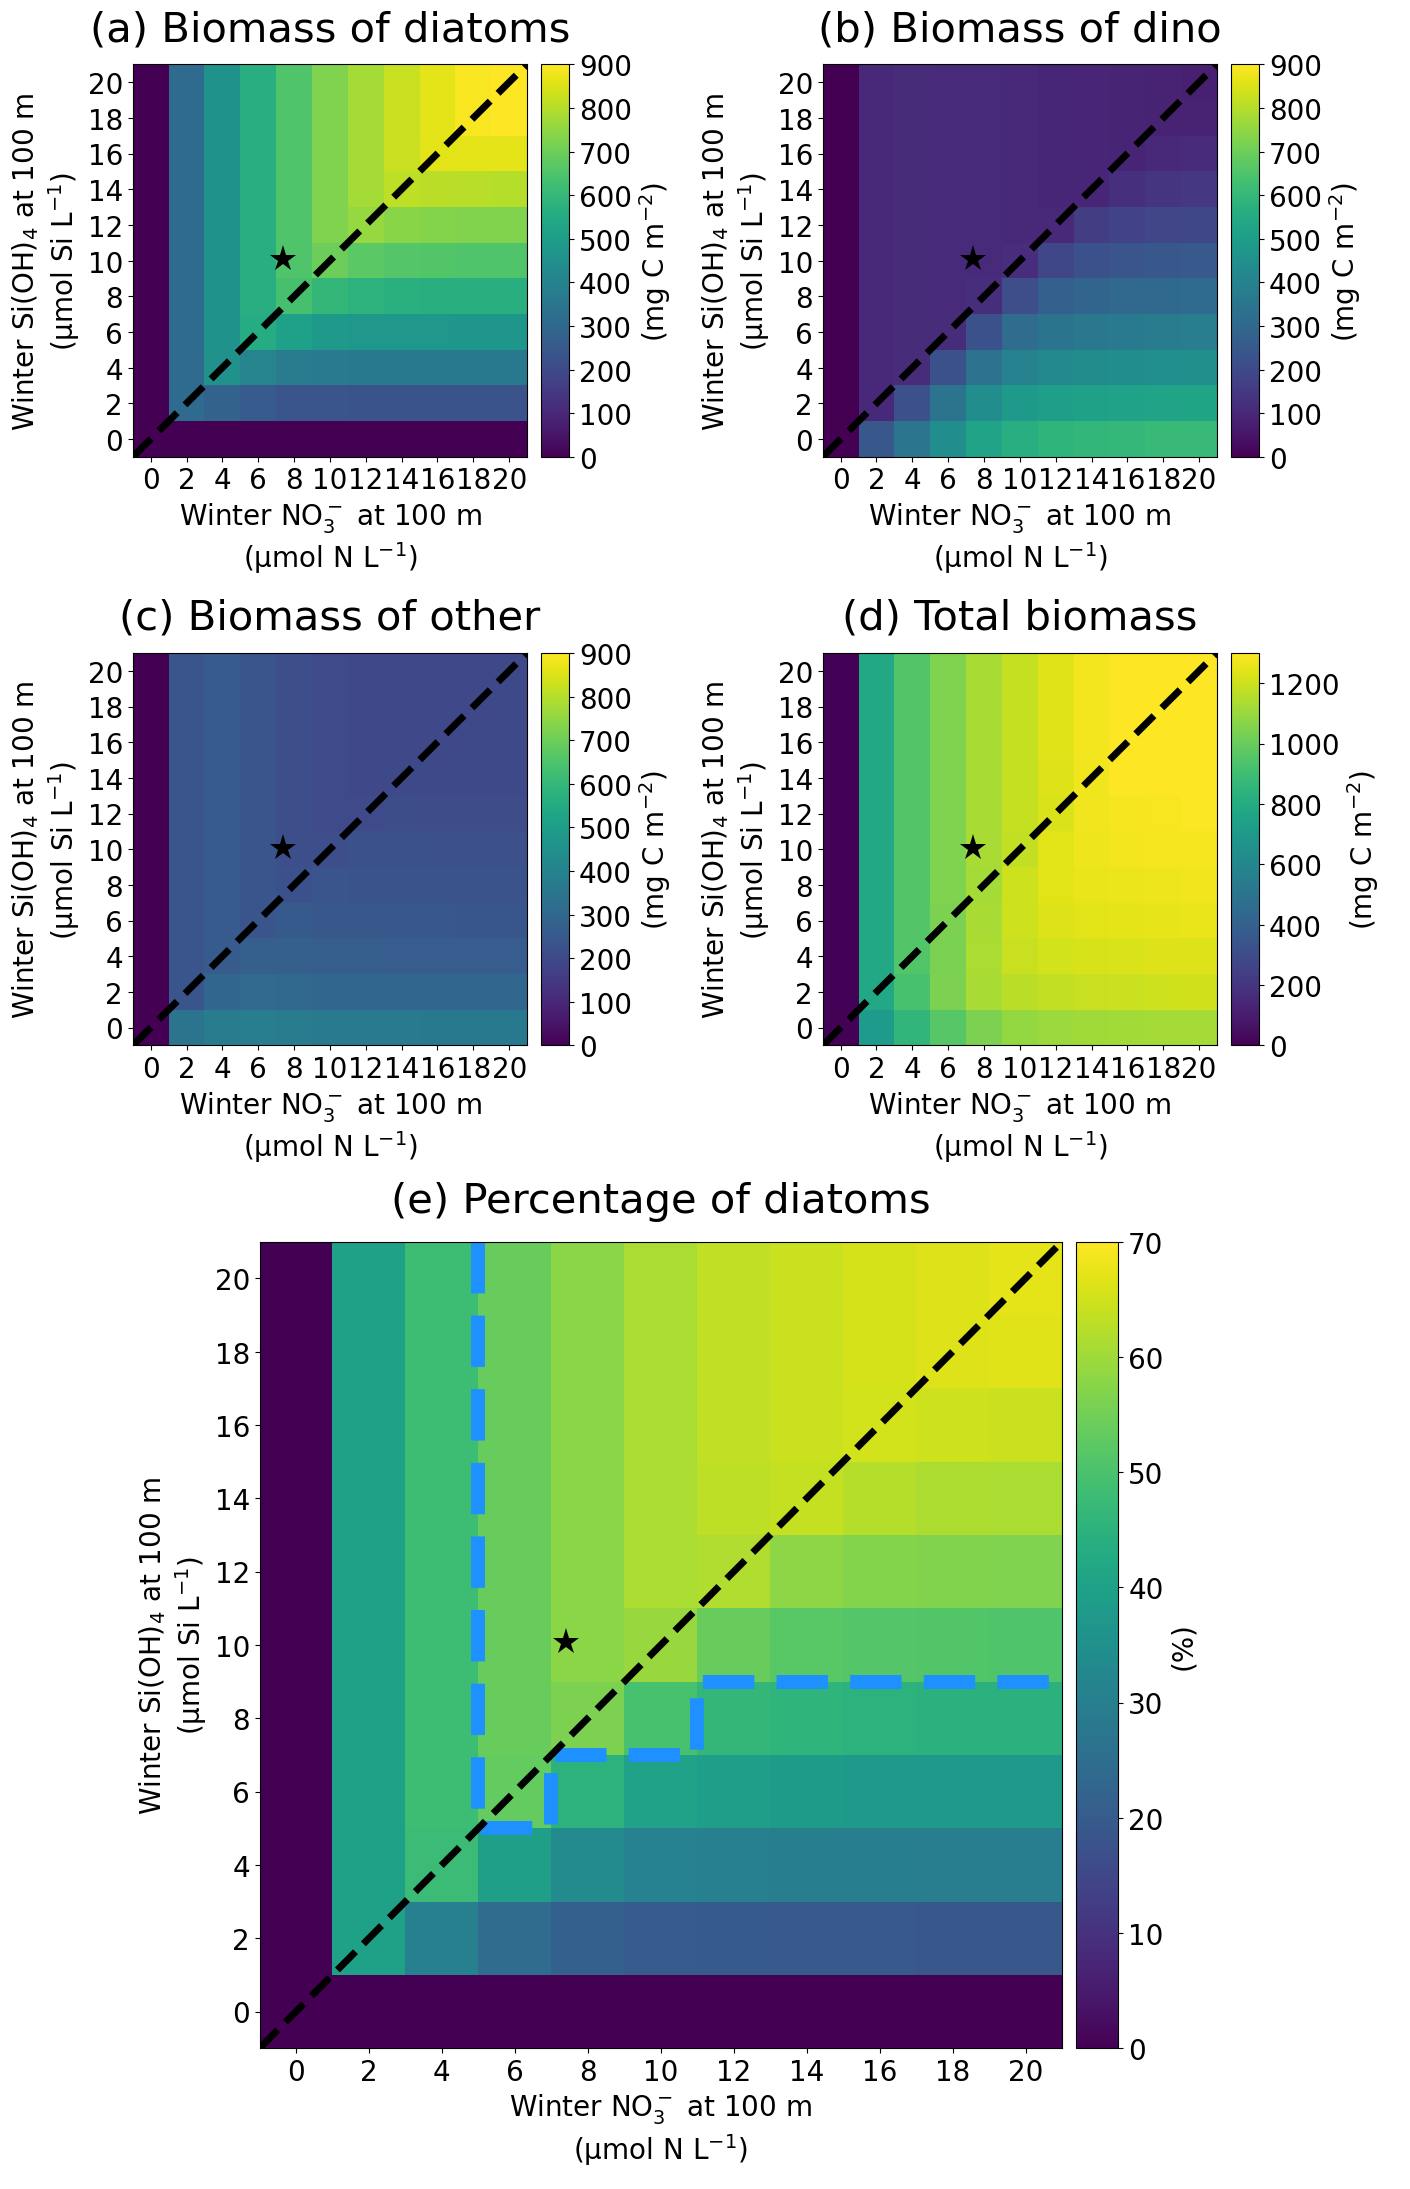

In [40]:
def make_plots(axs):
    
    # --- BIOMASS OF DIATOMS
    ax=axs[0,0]
    h=ax.pcolormesh(imeshno3,
                    imeshsi,
                    array2d_isi_ino3_diatoms_biomass/365*1000,
                    vmin=0,
                    vmax=900)
    ax.plot(no3_standard_100m,si_standard_100m,marker=marker)
    ax.set_xticks(sims_no3)
    ax.set_yticks(sims_si)
    ax.set_xlabel('Winter $\mathrm{ NO_3^- }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ N\ L^{-1} }$)')
    ax.set_ylabel('Winter $\mathrm{ Si(OH)_4 }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ Si\ L^{-1} }$)')
    cbaxes = fig.add_axes([0.39,0.79, 0.02,0.18])
    cbar=plt.colorbar(h,cax = cbaxes)
    cbar.set_label('($\mathrm{mg\ C\ m^{-2} }$)')
    plt.text(0.50,1.09,'(a) Biomass of diatoms',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes, fontsize=30)
    # diagonal
    ax.plot([-1,21],[-1,21],color='black',linestyle='--',linewidth=5)
    
    # --- BIOMASS OF DINOFLAGELLATES
    ax=axs[0,1]
    h=ax.pcolormesh(imeshno3,
                    imeshsi,
                    array2d_isi_ino3_dino_biomass/365*1000,
                    vmin=0,
                    vmax=900)
    ax.plot(no3_standard_100m,si_standard_100m,marker=marker)
    ax.set_xticks(sims_no3)
    ax.set_yticks(sims_si)
    ax.set_xlabel('Winter $\mathrm{ NO_3^- }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ N\ L^{-1} }$)')
    ax.set_ylabel('Winter $\mathrm{ Si(OH)_4 }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ Si\ L^{-1} }$)')
    cbaxes = fig.add_axes([0.39,0.52, 0.02,0.18])
    cbar=plt.colorbar(h,cax = cbaxes)
    cbar.set_label('($\mathrm{mg\ C\ m^{-2} }$)')
    plt.text(0.50,1.09,'(b) Biomass of dino',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes, fontsize=30)
    # diagonal
    ax.plot([-1,21],[-1,21],color='black',linestyle='--',linewidth=5)
    
    # --- BIOMASS OF OTHER NANOPHYTOPLANKTON
    ax=axs[1,0]
    h=ax.pcolormesh(imeshno3,
                    imeshsi,
                    array2d_isi_ino3_other_biomass/365*1000,
                    vmin=0,
                    vmax=900)
    ax.plot(no3_standard_100m,si_standard_100m,marker=marker)
    ax.set_xticks(sims_no3)
    ax.set_yticks(sims_si)
    ax.set_xlabel('Winter $\mathrm{ NO_3^- }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ N\ L^{-1} }$)')
    ax.set_ylabel('Winter $\mathrm{ Si(OH)_4 }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ Si\ L^{-1} }$)')
    cbaxes = fig.add_axes([0.88,0.79, 0.02,0.18])
    cbar=plt.colorbar(h,cax = cbaxes)
    cbar.set_label('($\mathrm{mg\ C\ m^{-2} }$)')
    plt.text(0.50,1.09,'(c) Biomass of other',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes, fontsize=30)
    # diagonal
    ax.plot([-1,21],[-1,21],color='black',linestyle='--',linewidth=5)
    
    # --- TOTAL BIOMASS
    ax=axs[1,1]
    h=ax.pcolormesh(imeshno3,
                    imeshsi,
                    array2d_isi_ino3_total_biomass/365*1000,
                    vmin=0,
                    vmax=1300)
    ax.plot(no3_standard_100m,si_standard_100m,marker=marker)
    ax.set_xticks(sims_no3)
    ax.set_yticks(sims_si)
    ax.set_xlabel('Winter $\mathrm{ NO_3^- }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ N\ L^{-1} }$)')
    ax.set_ylabel('Winter $\mathrm{ Si(OH)_4 }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ Si\ L^{-1} }$)')
    cbaxes = fig.add_axes([0.88,0.52, 0.02,0.18])
    cbar=plt.colorbar(h,cax = cbaxes)
    cbar.set_label('($\mathrm{mg\ C\ m^{-2} }$)')
    plt.text(0.50,1.09,'(d) Total biomass',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes, fontsize=30)
    # diagonal
    ax.plot([-1,21],[-1,21],color='black',linestyle='--',linewidth=5)
    
    # --- PERCENTAGE OF DIATOMS
    ax=axs[2,0]
    h=ax.pcolormesh(imeshno3,
                    imeshsi,
                    array2d_isi_ino3_diatoms_perc,
                    vmin=0,
                    vmax=70)
    ax.plot(no3_standard_100m,si_standard_100m,marker=marker)
    ax.set_xticks(sims_no3)
    ax.set_yticks(sims_si)
    ax.set_xlabel('Winter $\mathrm{ NO_3^- }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ N\ L^{-1} }$)')
    ax.set_ylabel('Winter $\mathrm{ Si(OH)_4 }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ Si\ L^{-1} }$)')
    cbaxes = fig.add_axes([0.77,0.06, 0.03,0.37])
    cbar=plt.colorbar(h,cax = cbaxes)
    cbar.set_label('(%)')
    plt.text(0.50,1.05,'(e) Percentage of diatoms',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes, fontsize=30)
    
    # enclose region where diatoms > 50%
    h=ax.plot(np.array(df.x),np.array(df.y),
              color='dodgerblue',linestyle='--')
    # diagonal
    ax.plot([-1,21],[-1,21],color='black',linestyle='--',linewidth=5)
    
    # --- NOTHING
    ax=axs[2,1]
    ax.axis('off')
    
    # --- POSITION
    axs[0,0].set_position([0.10,0.79, 0.28,0.18])
    axs[0,1].set_position([0.59,0.79, 0.28,0.18])
    axs[1,0].set_position([0.10,0.52, 0.28,0.18])
    axs[1,1].set_position([0.59,0.52, 0.28,0.18])
    axs[2,0].set_position([0.19,0.06, 0.57,0.37])
    axs[2,1].set_position([0.99,0.00, 0.01,0.01])

with plt.style.context('mplstyles/groups_exp2_3.mplstyle'):
    # Plot
    fig,axs=plt.subplots(nrows=3,ncols=2,figsize=(14.08,21.80))
    make_plots(axs)

    # --- SAVE
    outfile='figures/figure2.'+ext
    plt.savefig(outfile,dpi=dpi)

# Relative contribution of diatoms

In [41]:
circles={
    'circleIa':  {'x': 2,'y':14,'color':'black'},
    'circleIIa': {'x': 8,'y':14,'color':'black'},
    'circleIIb': {'x':16,'y':14,'color':'white'},
    'circleIIc': {'x':20,'y':14,'color':'white'},
    'circleIb':  {'x': 2,'y': 8,'color':'white'},
    'circleIIIa':{'x': 8,'y': 8,'color':'black'},
    'circleIVa': {'x':16,'y': 8,'color':'black'},
    'circleVa':  {'x': 2,'y': 2,'color':'black'},
    'circleVIa': {'x': 8,'y': 2,'color':'black'},
    'circleVIb': {'x':16,'y': 2,'color':'white'},
}
offset=0.1
domains={
    'domainI':{
        'vertices':np.array([[1,21-offset],
                             [1,5],
                             [5,5],
                             [5,21-offset]]),
        'text':    {'x':3,  'y':17, 'str':'I'}
    },
    'domainII':{
        'vertices':np.array([[5,21-offset],
                             [5,9],
                             [21-offset,9],
                             [21-offset,21-offset]]),
        'text':    {'x':13, 'y':17, 'str':'II'}
    },
    'domainIII':{
        'vertices':np.array([[5,9],
                             [5,5],
                             [9,5],
                             [9,9]]),
        'text':    {'x':7,  'y':7,  'str':'III'}
    },
    'domainIV':{
        'vertices':np.array([[9,9],
                             [9,5],
                             [21-offset,5],
                             [21-offset,9]]),
        'text':    {'x':15, 'y':7,  'str':'IV'}
    },
    'domainV':{
        'vertices':np.array([[1,5],
                             [1,-1+offset],
                             [5,-1+offset],
                             [5,5]]),
        'text':    {'x':3,  'y':2,  'str':'V'}
    },
    'domainVI':{
        'vertices':np.array([[5,5],
                             [5,-1+offset],
                             [21-offset,-1+offset],
                             [21-offset,5]]),
        'text':    {'x':13, 'y':2,  'str':'VI'}
    },
}

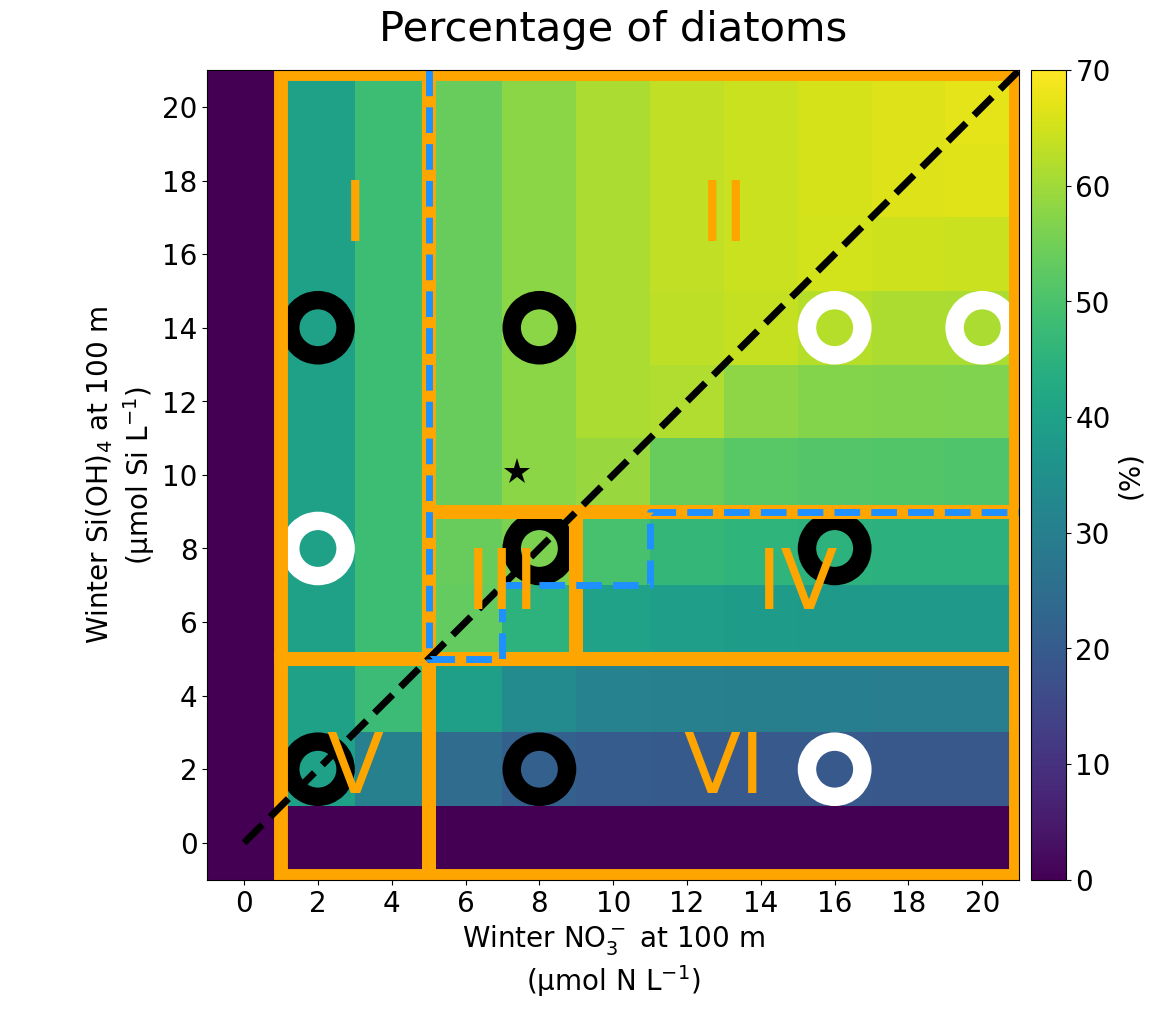

In [42]:
def make_plots(ax):
    
    # --- PERCENTAGE OF DIATOMS
    ax=axs[0]
    h=ax.pcolormesh(imeshno3,
                    imeshsi,
                    array2d_isi_ino3_diatoms_perc,
                    vmin=0,
                    vmax=70)
    ax.plot(no3_standard_100m,si_standard_100m,marker=marker)
    ax.set_xticks(sims_no3)
    ax.set_yticks(sims_si)
    ax.set_xlabel('Winter $\mathrm{ NO_3^- }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ N\ L^{-1} }$)')
    ax.set_ylabel('Winter $\mathrm{ Si(OH)_4 }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ Si\ L^{-1} }$)')
    cbaxes = fig.add_axes([0.88,0.11, 0.03,0.71])
    cbar=plt.colorbar(h,cax = cbaxes)
    cbar.set_label('(%)')
    plt.text(0.50,1.05,'Percentage of diatoms',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes, fontsize=30)
    
    # --- THEORETICAL LINES
    ax.plot([0,21],[0,21],color='black',
            linestyle='--',
            linewidth=5)
    
    # --- SIMULATIONS
    patches=[]
    colors=[]
    for circle in circles.values():
        x=circle['x']
        y=circle['y']
        color=circle['color']
        wedge=mpl.patches.Wedge(center=(x,y),
                                r=1,theta1=0,theta2=360,width=0.5)
        patches.append(wedge)
        colors.append(color)
    p=mpl.collections.PatchCollection(patches,facecolors=colors)
    ax.add_collection(p)
    
    # --- DOMAINS
    patches=[]
    for domain in domains.values():
        vertices=domain['vertices']
        text=domain['text']
        polygon=mpl.patches.Polygon(vertices,
                                    edgecolor='orange',fill=False,
                                   linewidth=10)
        ax.add_patch(polygon)
        ax.text(text['x'],text['y'],text['str'],
                color='orange',
                horizontalalignment='center',
                verticalalignment='center')
    
    
    # --- ENCLOSE REGION WHERE DIATOMS > 50%
    h=ax.plot(np.array(df.x),np.array(df.y),
              color='dodgerblue',linestyle='--')
    
    # --- NOTHING
    ax=axs[1]
    ax.axis('off')
    
    # --- POSITION
    axs[0].set_position([0.17,0.11, 0.70,0.71])
    axs[1].set_position([0.00,0.00, 0.01,0.01])

with plt.style.context('mplstyles/domains.mplstyle'):
    # Plot
    fig,axs=plt.subplots(nrows=2,figsize=(11.60,11.40))
    make_plots(axs)

    # --- SAVE
    outfile='figures/figure3.'+ext
    plt.savefig(outfile,dpi=dpi)

# Main experiments

## Main experiments: For all sensitivity simulations

In [43]:
set_automixo= \
['pro','syn','pico','other','diazo','tricho','diatoms','dino']

In [44]:
ip_automixo_list=[]
items=plankpy.__MAP_CXX_GROUP_SIZE__.items()
for group_name in ['diatoms','dino','other','pico']:
    ip_group=[k-1 for k,v in items if v[0]==group_name]
    ip_automixo_list=ip_automixo_list+ip_group[::-1]

## Main experiments: Simulation S14N02

Simulation with winter $\mathrm{ [Si(OH)_4] }$ at 100 m of 14 $\mathrm{ \mu mol\ Si\ L^{-1} }$ and winter $\mathrm{ [NO_3^-] }$ at 100 m of 2 $\mathrm{ \mu mol\ N\ L^{-1} }$ in domain I.

In [45]:
carfile\
='data/DataS4_outputs_long/run_'\
+yyyymmdd\
+'_0000_EXP2_3si_14_no3_02_122_sims/car.0000000000.t001.nc'

### Main experiments: Simulation S14N02: nutrients

In [46]:
array2d_idepth_iT_modno3full=netcdf_tools.read_netcdf(carfile, 'TRAC04').squeeze().transpose()
array2d_idepth_iT_modno3_s14n02=array2d_idepth_iT_modno3full[:,array1d_iT1y_iT]
array2d_idepth_iT_modsioh4full=netcdf_tools.read_netcdf(carfile, 'TRAC06').squeeze().transpose()
array2d_idepth_iT_modsioh4_s14n02=array2d_idepth_iT_modsioh4full[:,array1d_iT1y_iT]

### Main experiments: Simulation S14N02: plankton

#### Main experiments: Simulation S14N02: plankton: ecosystem

In [47]:
depth_end=100 # m
ecosystem=plankpy.Ecosystem(carfile=carfile,
                            gridfile=gridfile,
                            array1d_iT1y_iT=array1d_iT1y_iT,
                            depth_end=depth_end)

#### Main experiments: Simulation S14N02: plankton: total

Subsurface biomass maximum ($z_{SBM}$ in m).

In [48]:
set_automixo= \
['pro','syn','pico','other','diazo','tricho','diatoms','dino']
array1d_ip_gsautomixo=[v for \
                       v in plankpy.__MAP_CXX_GROUP_SIZE__.values()
                       if v[0] in set_automixo]
array2d_idepth_iT_cautomixo= \
ecosystem.get_array2d_idepth_iT_c(array1d_ip_gsautomixo)
ndays=array2d_idepth_iT_cautomixo.shape[1]
ndepths=RC.size
array1d_iT_izSBMautomixo_s14n02=np.full(ndays,-1,dtype=int)
array1d_iT_zSBMautomixo_s14n02 =np.full(ndays,np.nan)
for iT in range(ndays):
    array1d_idepth_cautomixo=array2d_idepth_iT_cautomixo[:,iT]
    idepthmax=np.nanargmax(array1d_idepth_cautomixo)
    array1d_iT_izSBMautomixo_s14n02[iT]=idepthmax
    # if exclude z_SBM when it is equal to the bathymetry
    if idepthmax<(ndepths-2):
        zSBMautomixo=RC[idepthmax]
    else:
        zSBMautomixo=np.nan
    array1d_iT_zSBMautomixo_s14n02[iT]=zSBMautomixo

#### Main experiments: Simulation S14N02: plankton: groups

$\mathrm{ C_g }$ is the biomass for group g in $\mathrm{ mg\ C\ m^{-3} }$.

$\mathrm{ \sum C_g }$ is the vertically integrated 
$\mathrm{ C_g }$ (0-100m) for group g in
$\mathrm{ g\ C\ m^{-2} }$.

In [49]:
# mg C m^-2 -> g C m^-2
array1d_iT_sumcpico_s14n02=ecosystem.get_group_sumc('pico')/1000
# mg C m^-2 -> g C m^-2
array1d_iT_sumcother_s14n02=ecosystem.get_group_sumc('other')/1000
# mg C m^-2 -> g C m^-2
array1d_iT_sumcdiatoms_s14n02=ecosystem.get_group_sumc('diatoms')/1000
# mg C m^-2 -> g C m^-2
array1d_iT_sumcdino_s14n02=ecosystem.get_group_sumc('dino')/1000
# mg C m^-2 -> g C m^-2
array1d_iT_sumczoo_s14n02=ecosystem.get_group_sumc('zoo')/1000

In [50]:
# for autotrophs + mixotrophs
array1d_iT_sumcautomixo_s14n02= \
array1d_iT_sumcpico_s14n02+array1d_iT_sumcother_s14n02 \
+array1d_iT_sumcdiatoms_s14n02+array1d_iT_sumcdino_s14n02

Model biomass (0-100m) bloom peak.

In [51]:
peak=np.nanargmax(array1d_iT_sumcautomixo_s14n02)
peak_s14n02=peak.item()
year=2016
peaks_s14n02=datetime.datetime(year,1,1)+datetime.timedelta(peak_s14n02)
peaks_s14n02.strftime("%B %d")

'July 20'

$z_{SBM}$ on the bloom peak in m.

In [52]:
array1d_iT_zSBMautomixo_s14n02[peak_s14n02]

41.6684945

$\mathrm{ [Si{(OH)}_4] }$ at the $z_{SBM}$ on the bloom peak in $\mathrm{ \mu mol\ Si\ L^{-1} }$.

In [53]:
izSBMautomixo=array1d_iT_izSBMautomixo_s14n02[peak_s14n02]
modsioh4_s14n02_peak\
=array2d_idepth_iT_modsioh4_s14n02[izSBMautomixo,peak_s14n02]
modsioh4_s14n02_peak

9.51386704650984

$\mathrm{ [NO_3] }$ at the $z_{SBM}$ on the bloom peak in $\mathrm{ \mu mol\ N\ L^{-1} }$.

In [54]:
modno3_s14n02_peak\
=array2d_idepth_iT_modno3_s14n02[izSBMautomixo,peak_s14n02]
modno3_s14n02_peak

0.2563415363445846

$\mathrm{ [NO_3] }$ at the $z_{SBM}$ in $\mathrm{ \mu mol\ N\ L^{-1} }$.

In [55]:
# for iT in first_year_from_may1:
#     d=datetime.datetime(2016,1,1)+datetime.timedelta(iT.item())
#     ds=d.strftime("%B %d")
#     izSBMautomixo=array1d_iT_izSBMautomixo_s14n02[iT]
#     modno3=array2d_idepth_iT_modno3_s14n02[izSBMautomixo,iT]
#     print('{0:3} {1:7} {2:7.3}'.format(iT,ds,modno3))

#### Main experiments: Simulation S14N02: plankton: types

$\mathrm{ C_p }$ is the biomass for plankton p in $\mathrm{ g\ C\ m^{-3} }$.

$\mathrm{ \sum C_p }$ is the vertically integrated 
$\mathrm{ C_p }$ (0-100m) for plankton p in
$\mathrm{ g\ C\ m^{-2} }$.

In [56]:
nautomixo=0
for group_name in set_automixo:
    nautomixo=nautomixo \
    +plankpy.Plankton.get_nsize_per_group(group_name)
group_name='pico'
size_name ='1.4'
plankton=ecosystem.get_plankton(group_name,size_name)
ndays=len(plankton.array1d_iT_sumc)
array2d_ip_iT_sumc_s14n02=np.zeros((nautomixo,ndays))
array2d_ip_iT_perc_s14n02=np.zeros((nautomixo,ndays))
for cxx in range(1,nautomixo+1):
    group_name,size_name=plankpy.Plankton.get_group_size(cxx)
    plankton=ecosystem.get_plankton(group_name,size_name)
    # mg C m^-2 -> g C m^-2
    array1d_iT_sumc=plankton.array1d_iT_sumc/1000
    array1d_iT_perc=array1d_iT_sumc/array1d_iT_sumcautomixo_s14n02*100
    for iT in range(0,ndays):
        array2d_ip_iT_sumc_s14n02[cxx-1,iT]=array1d_iT_sumc[iT]
        array2d_ip_iT_perc_s14n02[cxx-1,iT]=array1d_iT_perc[iT]

## Main experiments: Simulation S14N08

Simulation with winter $\mathrm{ [Si(OH)_4] }$ at 100 m of 14 $\mathrm{ \mu mol\ Si\ L^{-1} }$ and winter $\mathrm{ [NO_3^-] }$ at 100 m of 8 $\mathrm{ \mu mol\ N\ L^{-1} }$ in domain I.

In [57]:
carfile\
='data/DataS4_outputs_long/run_'\
+yyyymmdd\
+'_0000_EXP2_3si_14_no3_08_122_sims/car.0000000000.t001.nc'

### Main experiments: Simulation S14N08: nutrients

In [58]:
array2d_idepth_iT_modno3full=netcdf_tools.read_netcdf(carfile, 'TRAC04').squeeze().transpose()
array2d_idepth_iT_modno3_s14n08=array2d_idepth_iT_modno3full[:,array1d_iT1y_iT]
array2d_idepth_iT_modsioh4full=netcdf_tools.read_netcdf(carfile, 'TRAC06').squeeze().transpose()
array2d_idepth_iT_modsioh4_s14n08=array2d_idepth_iT_modsioh4full[:,array1d_iT1y_iT]

### Main experiments: Simulation S14N08: plankton

#### Main experiments: Simulation S14N08: plankton: ecosystem

In [59]:
depth_end=100 # m
ecosystem=plankpy.Ecosystem(carfile=carfile,
                            gridfile=gridfile,
                            array1d_iT1y_iT=array1d_iT1y_iT,
                            depth_end=depth_end)

#### Main experiments: Simulation S14N08: plankton: total

Subsurface biomass maximum ($z_{SBM}$ in m).

In [60]:
set_automixo= \
['pro','syn','pico','other','diazo','tricho','diatoms','dino']
array1d_ip_gsautomixo=[v for \
                       v in plankpy.__MAP_CXX_GROUP_SIZE__.values()
                       if v[0] in set_automixo]
array2d_idepth_iT_cautomixo= \
ecosystem.get_array2d_idepth_iT_c(array1d_ip_gsautomixo)
ndays=array2d_idepth_iT_cautomixo.shape[1]
ndepths=RC.size
array1d_iT_izSBMautomixo_s14n08=np.full(ndays,-1,dtype=int)
array1d_iT_zSBMautomixo_s14n08 =np.full(ndays,np.nan)
for iT in range(ndays):
    array1d_idepth_cautomixo=array2d_idepth_iT_cautomixo[:,iT]
    idepthmax=np.nanargmax(array1d_idepth_cautomixo)
    array1d_iT_izSBMautomixo_s14n08[iT]=idepthmax
    # if exclude z_SBM when it is equal to the bathymetry
    if idepthmax<(ndepths-2):
        zSBMautomixo=RC[idepthmax]
    else:
        zSBMautomixo=np.nan
    array1d_iT_zSBMautomixo_s14n08[iT]=zSBMautomixo

#### Main experiments: Simulation S14N08: plankton: groups

$\mathrm{ C_g }$ is the biomass for group g in $\mathrm{ mg\ C\ m^{-3} }$.

$\mathrm{ \sum C_g }$ is the vertically integrated 
$\mathrm{ C_g }$ (0-100m) for group g in
$\mathrm{ g\ C\ m^{-2} }$.

In [61]:
# mg C m^-2 -> g C m^-2
array1d_iT_sumcpico_s14n08=ecosystem.get_group_sumc('pico')/1000
# mg C m^-2 -> g C m^-2
array1d_iT_sumcother_s14n08=ecosystem.get_group_sumc('other')/1000
# mg C m^-2 -> g C m^-2
array1d_iT_sumcdiatoms_s14n08=ecosystem.get_group_sumc('diatoms')/1000
# mg C m^-2 -> g C m^-2
array1d_iT_sumcdino_s14n08=ecosystem.get_group_sumc('dino')/1000
# mg C m^-2 -> g C m^-2
array1d_iT_sumczoo_s14n08=ecosystem.get_group_sumc('zoo')/1000

In [62]:
# for autotrophs + mixotrophs
array1d_iT_sumcautomixo_s14n08= \
array1d_iT_sumcpico_s14n08+array1d_iT_sumcother_s14n08 \
+array1d_iT_sumcdiatoms_s14n08+array1d_iT_sumcdino_s14n08

Model biomass (0-100m) bloom peak.

In [63]:
peak=np.nanargmax(array1d_iT_sumcautomixo_s14n08)
peak_s14n08=peak.item()
year=2016
peaks_s14n08=datetime.datetime(year,1,1)+datetime.timedelta(peak_s14n08)
peaks_s14n08.strftime("%B %d")

'July 27'

$z_{SBM}$ on the bloom peak in m.

In [64]:
array1d_iT_zSBMautomixo_s14n08[peak_s14n08]

32.883559500000004

$\mathrm{ [Si{(OH)}_4] }$ at the $z_{SBM}$ on the bloom peak in $\mathrm{ \mu mol\ Si\ L^{-1} }$.

In [65]:
izSBMautomixo=array1d_iT_izSBMautomixo_s14n08[peak_s14n08]
modsioh4_s14n08_peak\
=array2d_idepth_iT_modsioh4_s14n08[izSBMautomixo,peak_s14n08]
modsioh4_s14n08_peak

6.7102801703060635

$\mathrm{ [NO_3] }$ at the $z_{SBM}$ on the bloom peak in $\mathrm{ \mu mol\ N\ L^{-1} }$.

In [66]:
modno3_s14n08_peak\
=array2d_idepth_iT_modno3_s14n08[izSBMautomixo,peak_s14n08]
modno3_s14n08_peak

2.030190788511187

#### Main experiments: Simulation S14N08: plankton: types

$\mathrm{ C_p }$ is the biomass for plankton p in $\mathrm{ g\ C\ m^{-3} }$.

$\mathrm{ \sum C_p }$ is the vertically integrated 
$\mathrm{ C_p }$ (0-100m) for plankton p in
$\mathrm{ g\ C\ m^{-2} }$.

In [67]:
nautomixo=0
for group_name in set_automixo:
    nautomixo=nautomixo \
    +plankpy.Plankton.get_nsize_per_group(group_name)
group_name='pico'
size_name ='1.4'
plankton=ecosystem.get_plankton(group_name,size_name)
ndays=len(plankton.array1d_iT_sumc)
array2d_ip_iT_sumc_s14n08=np.zeros((nautomixo,ndays))
array2d_ip_iT_perc_s14n08=np.zeros((nautomixo,ndays))
for cxx in range(1,nautomixo+1):
    group_name,size_name=plankpy.Plankton.get_group_size(cxx)
    plankton=ecosystem.get_plankton(group_name,size_name)
    # mg C m^-2 -> g C m^-2
    array1d_iT_sumc=plankton.array1d_iT_sumc/1000
    array1d_iT_perc=array1d_iT_sumc/array1d_iT_sumcautomixo_s14n08*100
    for iT in range(0,ndays):
        array2d_ip_iT_sumc_s14n08[cxx-1,iT]=array1d_iT_sumc[iT]
        array2d_ip_iT_perc_s14n08[cxx-1,iT]=array1d_iT_perc[iT]

## Main experiments: Simulation S08N08

Simulation with winter $\mathrm{ [Si(OH)_4] }$ at 100 m of 8 $\mathrm{ \mu mol\ Si\ L^{-1} }$ and winter $\mathrm{ [NO_3^-] }$ at 100 m of 8 $\mathrm{ \mu mol\ N\ L^{-1} }$ in domain I.

In [68]:
carfile\
='data/DataS4_outputs_long/run_'\
+yyyymmdd\
+'_0000_EXP2_3si_08_no3_08_122_sims/car.0000000000.t001.nc'

### Main experiments: Simulation S08N08: nutrients

In [69]:
array2d_idepth_iT_modno3full=netcdf_tools.read_netcdf(carfile, 'TRAC04').squeeze().transpose()
array2d_idepth_iT_modno3_s08n08=array2d_idepth_iT_modno3full[:,array1d_iT1y_iT]
array2d_idepth_iT_modsioh4full=netcdf_tools.read_netcdf(carfile, 'TRAC06').squeeze().transpose()
array2d_idepth_iT_modsioh4_s08n08=array2d_idepth_iT_modsioh4full[:,array1d_iT1y_iT]

### Main experiments: Simulation S08N08: plankton

#### Main experiments: Simulation S08N08: plankton: ecosystem

In [70]:
depth_end=100 # m
ecosystem=plankpy.Ecosystem(carfile=carfile,
                            gridfile=gridfile,
                            array1d_iT1y_iT=array1d_iT1y_iT,
                            depth_end=depth_end)

#### Main experiments: Simulation S08N08: plankton: total

Subsurface biomass maximum ($z_{SBM}$ in m).

In [71]:
set_automixo= \
['pro','syn','pico','other','diazo','tricho','diatoms','dino']
array1d_ip_gsautomixo=[v for \
                       v in plankpy.__MAP_CXX_GROUP_SIZE__.values()
                       if v[0] in set_automixo]
array2d_idepth_iT_cautomixo= \
ecosystem.get_array2d_idepth_iT_c(array1d_ip_gsautomixo)
ndays=array2d_idepth_iT_cautomixo.shape[1]
ndepths=RC.size
array1d_iT_izSBMautomixo_s08n08=np.full(ndays,-1,dtype=int)
array1d_iT_zSBMautomixo_s08n08 =np.full(ndays,np.nan)
for iT in range(ndays):
    array1d_idepth_cautomixo=array2d_idepth_iT_cautomixo[:,iT]
    idepthmax=np.nanargmax(array1d_idepth_cautomixo)
    array1d_iT_izSBMautomixo_s08n08[iT]=idepthmax
    # if exclude z_SBM when it is equal to the bathymetry
    if idepthmax<(ndepths-2):
        zSBMautomixo=RC[idepthmax]
    else:
        zSBMautomixo=np.nan
    array1d_iT_zSBMautomixo_s08n08[iT]=zSBMautomixo

#### Main experiments: Simulation S08N08: plankton: groups

$\mathrm{ C_g }$ is the biomass for group g in $\mathrm{ mg\ C\ m^{-3} }$.

$\mathrm{ \sum C_g }$ is the vertically integrated 
$\mathrm{ C_g }$ (0-100m) for group g in
$\mathrm{ g\ C\ m^{-2} }$.

In [72]:
# mg C m^-2 -> g C m^-2
array1d_iT_sumcpico_s08n08=ecosystem.get_group_sumc('pico')/1000
# mg C m^-2 -> g C m^-2
array1d_iT_sumcother_s08n08=ecosystem.get_group_sumc('other')/1000
# mg C m^-2 -> g C m^-2
array1d_iT_sumcdiatoms_s08n08=ecosystem.get_group_sumc('diatoms')/1000
# mg C m^-2 -> g C m^-2
array1d_iT_sumcdino_s08n08=ecosystem.get_group_sumc('dino')/1000
# mg C m^-2 -> g C m^-2
array1d_iT_sumczoo_s08n08=ecosystem.get_group_sumc('zoo')/1000

In [73]:
# for autotrophs + mixotrophs
array1d_iT_sumcautomixo_s08n08= \
array1d_iT_sumcpico_s08n08+array1d_iT_sumcother_s08n08 \
+array1d_iT_sumcdiatoms_s08n08+array1d_iT_sumcdino_s08n08

Model biomass (0-100m) bloom peak.

In [74]:
peak=np.nanargmax(array1d_iT_sumcautomixo_s08n08)
peak_s08n08=peak.item()
year=2016
peaks_s08n08=datetime.datetime(year,1,1)+datetime.timedelta(peak_s08n08)
peaks_s08n08.strftime("%B %d")

'July 27'

$z_{SBM}$ on the bloom peak in m.

In [75]:
array1d_iT_zSBMautomixo_s08n08[peak_s08n08]

32.883559500000004

$\mathrm{ [Si{(OH)}_4] }$ at the $z_{SBM}$ on the bloom peak in $\mathrm{ \mu mol\ Si\ L^{-1} }$.

In [76]:
izSBMautomixo=array1d_iT_izSBMautomixo_s08n08[peak_s08n08]
modsioh4_s08n08_peak\
=array2d_idepth_iT_modsioh4_s08n08[izSBMautomixo,peak_s08n08]
modsioh4_s08n08_peak

2.2269171319430465

$\mathrm{ [NO_3] }$ at the $z_{SBM}$ on the bloom peak in $\mathrm{ \mu mol\ N\ L^{-1} }$.

In [77]:
modno3_s08n08_peak\
=array2d_idepth_iT_modno3_s08n08[izSBMautomixo,peak_s08n08]
modno3_s08n08_peak

2.0165444868695097

#### Main experiments: Simulation S08N08: plankton: types

$\mathrm{ C_p }$ is the biomass for plankton p in $\mathrm{ g\ C\ m^{-3} }$.

$\mathrm{ \sum C_p }$ is the vertically integrated 
$\mathrm{ C_p }$ (0-100m) for plankton p in
$\mathrm{ g\ C\ m^{-2} }$.

In [78]:
nautomixo=0
for group_name in set_automixo:
    nautomixo=nautomixo \
    +plankpy.Plankton.get_nsize_per_group(group_name)
group_name='pico'
size_name ='1.4'
plankton=ecosystem.get_plankton(group_name,size_name)
ndays=len(plankton.array1d_iT_sumc)
array2d_ip_iT_sumc_s08n08=np.zeros((nautomixo,ndays))
array2d_ip_iT_perc_s08n08=np.zeros((nautomixo,ndays))
for cxx in range(1,nautomixo+1):
    group_name,size_name=plankpy.Plankton.get_group_size(cxx)
    plankton=ecosystem.get_plankton(group_name,size_name)
    # mg C m^-2 -> g C m^-2
    array1d_iT_sumc=plankton.array1d_iT_sumc/1000
    array1d_iT_perc=array1d_iT_sumc/array1d_iT_sumcautomixo_s08n08*100
    for iT in range(0,ndays):
        array2d_ip_iT_sumc_s08n08[cxx-1,iT]=array1d_iT_sumc[iT]
        array2d_ip_iT_perc_s08n08[cxx-1,iT]=array1d_iT_perc[iT]

## Main experiments: Simulation S08N16

Simulation with winter $\mathrm{ [Si(OH)_4] }$ at 100 m of 8 $\mathrm{ \mu mol\ Si\ L^{-1} }$ and winter $\mathrm{ [NO_3^-] }$ at 100 m of 16 $\mathrm{ \mu mol\ N\ L^{-1} }$ in domain I.

In [79]:
carfile\
='data/DataS4_outputs_long/run_'\
+yyyymmdd\
+'_0000_EXP2_3si_08_no3_16_122_sims/car.0000000000.t001.nc'

### Main experiments: Simulation S08N16: nutrients

In [80]:
array2d_idepth_iT_modno3full=netcdf_tools.read_netcdf(carfile, 'TRAC04').squeeze().transpose()
array2d_idepth_iT_modno3_s08n16=array2d_idepth_iT_modno3full[:,array1d_iT1y_iT]
array2d_idepth_iT_modsioh4full=netcdf_tools.read_netcdf(carfile, 'TRAC06').squeeze().transpose()
array2d_idepth_iT_modsioh4_s08n16=array2d_idepth_iT_modsioh4full[:,array1d_iT1y_iT]

### Main experiments: Simulation S08N16: plankton

#### Main experiments: Simulation S08N16: plankton: ecosystem

In [81]:
depth_end=100 # m
ecosystem=plankpy.Ecosystem(carfile=carfile,
                            gridfile=gridfile,
                            array1d_iT1y_iT=array1d_iT1y_iT,
                            depth_end=depth_end)

#### Main experiments: Simulation S08N16: plankton: total

Subsurface biomass maximum ($z_{SBM}$ in m).

In [82]:
set_automixo= \
['pro','syn','pico','other','diazo','tricho','diatoms','dino']
array1d_ip_gsautomixo=[v for \
                       v in plankpy.__MAP_CXX_GROUP_SIZE__.values()
                       if v[0] in set_automixo]
array2d_idepth_iT_cautomixo= \
ecosystem.get_array2d_idepth_iT_c(array1d_ip_gsautomixo)
ndays=array2d_idepth_iT_cautomixo.shape[1]
ndepths=RC.size
array1d_iT_izSBMautomixo_s08n16=np.full(ndays,-1,dtype=int)
array1d_iT_zSBMautomixo_s08n16 =np.full(ndays,np.nan)
for iT in range(ndays):
    array1d_idepth_cautomixo=array2d_idepth_iT_cautomixo[:,iT]
    idepthmax=np.nanargmax(array1d_idepth_cautomixo)
    array1d_iT_izSBMautomixo_s08n16[iT]=idepthmax
    # if exclude z_SBM when it is equal to the bathymetry
    if idepthmax<(ndepths-2):
        zSBMautomixo=RC[idepthmax]
    else:
        zSBMautomixo=np.nan
    array1d_iT_zSBMautomixo_s08n16[iT]=zSBMautomixo

#### Main experiments: Simulation S08N16: plankton: groups

$\mathrm{ C_g }$ is the biomass for group g in $\mathrm{ mg\ C\ m^{-3} }$.

$\mathrm{ \sum C_g }$ is the vertically integrated 
$\mathrm{ C_g }$ (0-100m) for group g in
$\mathrm{ g\ C\ m^{-2} }$.

In [83]:
# mg C m^-2 -> g C m^-2
array1d_iT_sumcpico_s08n16=ecosystem.get_group_sumc('pico')/1000
# mg C m^-2 -> g C m^-2
array1d_iT_sumcother_s08n16=ecosystem.get_group_sumc('other')/1000
# mg C m^-2 -> g C m^-2
array1d_iT_sumcdiatoms_s08n16=ecosystem.get_group_sumc('diatoms')/1000
# mg C m^-2 -> g C m^-2
array1d_iT_sumcdino_s08n16=ecosystem.get_group_sumc('dino')/1000
# mg C m^-2 -> g C m^-2
array1d_iT_sumczoo_s08n16=ecosystem.get_group_sumc('zoo')/1000

In [84]:
# for autotrophs + mixotrophs
array1d_iT_sumcautomixo_s08n16= \
array1d_iT_sumcpico_s08n16+array1d_iT_sumcother_s08n16 \
+array1d_iT_sumcdiatoms_s08n16+array1d_iT_sumcdino_s08n16

Model biomass (0-100m) bloom peak.

In [85]:
peak=np.nanargmax(array1d_iT_sumcautomixo_s08n16)
peak_s08n16=peak.item()
year=2016
peaks_s08n16=datetime.datetime(year,1,1)+datetime.timedelta(peak_s08n16)
peaks_s08n16.strftime("%B %d")

'July 28'

$z_{SBM}$ on the bloom peak in m.

In [86]:
array1d_iT_zSBMautomixo_s08n16[peak_s08n16]

32.883559500000004

$\mathrm{ [Si{(OH)}_4] }$ at the $z_{SBM}$ on the bloom peak in $\mathrm{ \mu mol\ Si\ L^{-1} }$.

In [87]:
izSBMautomixo=array1d_iT_izSBMautomixo_s08n16[peak_s08n16]
modsioh4_s08n16_peak\
=array2d_idepth_iT_modsioh4_s08n16[izSBMautomixo,peak_s08n16]
modsioh4_s08n16_peak

2.086761527099556

$\mathrm{ [NO_3] }$ at the $z_{SBM}$ on the bloom peak in $\mathrm{ \mu mol\ N\ L^{-1} }$.

In [88]:
modno3_s08n16_peak\
=array2d_idepth_iT_modno3_s08n16[izSBMautomixo,peak_s08n16]
modno3_s08n16_peak

7.378793313873406

#### Main experiments: Simulation S08N16: plankton: types

$\mathrm{ C_p }$ is the biomass for plankton p in $\mathrm{ g\ C\ m^{-3} }$.

$\mathrm{ \sum C_p }$ is the vertically integrated 
$\mathrm{ C_p }$ (0-100m) for plankton p in
$\mathrm{ g\ C\ m^{-2} }$.

In [89]:
nautomixo=0
for group_name in set_automixo:
    nautomixo=nautomixo \
    +plankpy.Plankton.get_nsize_per_group(group_name)
group_name='pico'
size_name ='1.4'
plankton=ecosystem.get_plankton(group_name,size_name)
ndays=len(plankton.array1d_iT_sumc)
array2d_ip_iT_sumc_s08n16=np.zeros((nautomixo,ndays))
array2d_ip_iT_perc_s08n16=np.zeros((nautomixo,ndays))
for cxx in range(1,nautomixo+1):
    group_name,size_name=plankpy.Plankton.get_group_size(cxx)
    plankton=ecosystem.get_plankton(group_name,size_name)
    # mg C m^-2 -> g C m^-2
    array1d_iT_sumc=plankton.array1d_iT_sumc/1000
    array1d_iT_perc=array1d_iT_sumc/array1d_iT_sumcautomixo_s08n16*100
    for iT in range(0,ndays):
        array2d_ip_iT_sumc_s08n16[cxx-1,iT]=array1d_iT_sumc[iT]
        array2d_ip_iT_perc_s08n16[cxx-1,iT]=array1d_iT_perc[iT]

## Main experiments: Simulation S02N02

Simulation with winter $\mathrm{ [Si(OH)_4] }$ at 100 m of 2 $\mathrm{ \mu mol\ Si\ L^{-1} }$ and winter $\mathrm{ [NO_3^-] }$ at 100 m of 2 $\mathrm{ \mu mol\ N\ L^{-1} }$ in domain I.

In [90]:
carfile\
='data/DataS4_outputs_long/run_'\
+yyyymmdd\
+'_0000_EXP2_3si_02_no3_02_122_sims/car.0000000000.t001.nc'

### Main experiments: Simulation S02N02: nutrients

In [91]:
array2d_idepth_iT_modno3full=netcdf_tools.read_netcdf(carfile, 'TRAC04').squeeze().transpose()
array2d_idepth_iT_modno3_s02n02=array2d_idepth_iT_modno3full[:,array1d_iT1y_iT]
array2d_idepth_iT_modsioh4full=netcdf_tools.read_netcdf(carfile, 'TRAC06').squeeze().transpose()
array2d_idepth_iT_modsioh4_s02n02=array2d_idepth_iT_modsioh4full[:,array1d_iT1y_iT]

### Main experiments: Simulation S02N02: plankton

#### Main experiments: Simulation S02N02: plankton: ecosystem

In [92]:
depth_end=100 # m
ecosystem=plankpy.Ecosystem(carfile=carfile,
                            gridfile=gridfile,
                            array1d_iT1y_iT=array1d_iT1y_iT,
                            depth_end=depth_end)

#### Main experiments: Simulation S02N02: plankton: total

Subsurface biomass maximum ($z_{SBM}$ in m).

In [93]:
set_automixo= \
['pro','syn','pico','other','diazo','tricho','diatoms','dino']
array1d_ip_gsautomixo=[v for \
                       v in plankpy.__MAP_CXX_GROUP_SIZE__.values()
                       if v[0] in set_automixo]
array2d_idepth_iT_cautomixo= \
ecosystem.get_array2d_idepth_iT_c(array1d_ip_gsautomixo)
ndays=array2d_idepth_iT_cautomixo.shape[1]
ndepths=RC.size
array1d_iT_izSBMautomixo_s02n02=np.full(ndays,-1,dtype=int)
array1d_iT_zSBMautomixo_s02n02 =np.full(ndays,np.nan)
for iT in range(ndays):
    array1d_idepth_cautomixo=array2d_idepth_iT_cautomixo[:,iT]
    idepthmax=np.nanargmax(array1d_idepth_cautomixo)
    array1d_iT_izSBMautomixo_s02n02[iT]=idepthmax
    # if exclude z_SBM when it is equal to the bathymetry
    if idepthmax<(ndepths-2):
        zSBMautomixo=RC[idepthmax]
    else:
        zSBMautomixo=np.nan
    array1d_iT_zSBMautomixo_s02n02[iT]=zSBMautomixo

#### Main experiments: Simulation S02N02: plankton: groups

$\mathrm{ C_g }$ is the biomass for group g in $\mathrm{ mg\ C\ m^{-3} }$.

$\mathrm{ \sum C_g }$ is the vertically integrated 
$\mathrm{ C_g }$ (0-100m) for group g in
$\mathrm{ g\ C\ m^{-2} }$.

In [94]:
# mg C m^-2 -> g C m^-2
array1d_iT_sumcpico_s02n02=ecosystem.get_group_sumc('pico')/1000
# mg C m^-2 -> g C m^-2
array1d_iT_sumcother_s02n02=ecosystem.get_group_sumc('other')/1000
# mg C m^-2 -> g C m^-2
array1d_iT_sumcdiatoms_s02n02=ecosystem.get_group_sumc('diatoms')/1000
# mg C m^-2 -> g C m^-2
array1d_iT_sumcdino_s02n02=ecosystem.get_group_sumc('dino')/1000
# mg C m^-2 -> g C m^-2
array1d_iT_sumczoo_s02n02=ecosystem.get_group_sumc('zoo')/1000

In [95]:
# for autotrophs + mixotrophs
array1d_iT_sumcautomixo_s02n02= \
array1d_iT_sumcpico_s02n02+array1d_iT_sumcother_s02n02 \
+array1d_iT_sumcdiatoms_s02n02+array1d_iT_sumcdino_s02n02

Model biomass (0-100m) bloom peak.

In [96]:
peak=np.nanargmax(array1d_iT_sumcautomixo_s02n02)
peak_s02n02=peak.item()
year=2016
peaks_s02n02=datetime.datetime(year,1,1)+datetime.timedelta(peak_s02n02)
peaks_s02n02.strftime("%B %d")

'July 20'

$z_{SBM}$ on the bloom peak in m.

In [97]:
array1d_iT_zSBMautomixo_s02n02[peak_s02n02]

41.6684945

$\mathrm{ [Si{(OH)}_4] }$ at the $z_{SBM}$ on the bloom peak in $\mathrm{ \mu mol\ Si\ L^{-1} }$.

In [98]:
izSBMautomixo=array1d_iT_izSBMautomixo_s02n02[peak_s02n02]
modsioh4_s02n02_peak\
=array2d_idepth_iT_modsioh4_s02n02[izSBMautomixo,peak_s02n02]
modsioh4_s02n02_peak

0.4067235186588916

$\mathrm{ [NO_3] }$ at the $z_{SBM}$ on the bloom peak in $\mathrm{ \mu mol\ N\ L^{-1} }$.

In [99]:
modno3_s02n02_peak\
=array2d_idepth_iT_modno3_s02n02[izSBMautomixo,peak_s02n02]
modno3_s02n02_peak

0.2695361668544832

#### Main experiments: Simulation S02N02: plankton: types

$\mathrm{ C_p }$ is the biomass for plankton p in $\mathrm{ g\ C\ m^{-3} }$.

$\mathrm{ \sum C_p }$ is the vertically integrated 
$\mathrm{ C_p }$ (0-100m) for plankton p in
$\mathrm{ g\ C\ m^{-2} }$.

In [100]:
nautomixo=0
for group_name in set_automixo:
    nautomixo=nautomixo \
    +plankpy.Plankton.get_nsize_per_group(group_name)
group_name='pico'
size_name ='1.4'
plankton=ecosystem.get_plankton(group_name,size_name)
ndays=len(plankton.array1d_iT_sumc)
array2d_ip_iT_sumc_s02n02=np.zeros((nautomixo,ndays))
array2d_ip_iT_perc_s02n02=np.zeros((nautomixo,ndays))
for cxx in range(1,nautomixo+1):
    group_name,size_name=plankpy.Plankton.get_group_size(cxx)
    plankton=ecosystem.get_plankton(group_name,size_name)
    # mg C m^-2 -> g C m^-2
    array1d_iT_sumc=plankton.array1d_iT_sumc/1000
    array1d_iT_perc=array1d_iT_sumc/array1d_iT_sumcautomixo_s02n02*100
    for iT in range(0,ndays):
        array2d_ip_iT_sumc_s02n02[cxx-1,iT]=array1d_iT_sumc[iT]
        array2d_ip_iT_perc_s02n02[cxx-1,iT]=array1d_iT_perc[iT]

## Main experiments: Simulation S02N08

Simulation with winter $\mathrm{ [Si(OH)_4] }$ at 100 m of 2 $\mathrm{ \mu mol\ Si\ L^{-1} }$ and winter $\mathrm{ [NO_3^-] }$ at 100 m of 8 $\mathrm{ \mu mol\ N\ L^{-1} }$ in domain I.

In [101]:
carfile\
='data/DataS4_outputs_long/run_'\
+yyyymmdd\
+'_0000_EXP2_3si_02_no3_08_122_sims/car.0000000000.t001.nc'

### Main experiments: Simulation S02N08: nutrients

In [102]:
array2d_idepth_iT_modno3full=netcdf_tools.read_netcdf(carfile, 'TRAC04').squeeze().transpose()
array2d_idepth_iT_modno3_s02n08=array2d_idepth_iT_modno3full[:,array1d_iT1y_iT]
array2d_idepth_iT_modsioh4full=netcdf_tools.read_netcdf(carfile, 'TRAC06').squeeze().transpose()
array2d_idepth_iT_modsioh4_s02n08=array2d_idepth_iT_modsioh4full[:,array1d_iT1y_iT]

### Main experiments: Simulation S02N08: plankton

#### Main experiments: Simulation S02N08: plankton: ecosystem

In [103]:
depth_end=100 # m
ecosystem=plankpy.Ecosystem(carfile=carfile,
                            gridfile=gridfile,
                            array1d_iT1y_iT=array1d_iT1y_iT,
                            depth_end=depth_end)

#### Main experiments: Simulation S02N08: plankton: total

Subsurface biomass maximum ($z_{SBM}$ in m).

In [104]:
set_automixo= \
['pro','syn','pico','other','diazo','tricho','diatoms','dino']
array1d_ip_gsautomixo=[v for \
                       v in plankpy.__MAP_CXX_GROUP_SIZE__.values()
                       if v[0] in set_automixo]
array2d_idepth_iT_cautomixo= \
ecosystem.get_array2d_idepth_iT_c(array1d_ip_gsautomixo)
ndays=array2d_idepth_iT_cautomixo.shape[1]
ndepths=RC.size
array1d_iT_izSBMautomixo_s02n08=np.full(ndays,-1,dtype=int)
array1d_iT_zSBMautomixo_s02n08 =np.full(ndays,np.nan)
for iT in range(ndays):
    array1d_idepth_cautomixo=array2d_idepth_iT_cautomixo[:,iT]
    idepthmax=np.nanargmax(array1d_idepth_cautomixo)
    array1d_iT_izSBMautomixo_s02n08[iT]=idepthmax
    # if exclude z_SBM when it is equal to the bathymetry
    if idepthmax<(ndepths-2):
        zSBMautomixo=RC[idepthmax]
    else:
        zSBMautomixo=np.nan
    array1d_iT_zSBMautomixo_s02n08[iT]=zSBMautomixo

#### Main experiments: Simulation S02N08: plankton: groups

$\mathrm{ C_g }$ is the biomass for group g in $\mathrm{ mg\ C\ m^{-3} }$.

$\mathrm{ \sum C_g }$ is the vertically integrated 
$\mathrm{ C_g }$ (0-100m) for group g in
$\mathrm{ g\ C\ m^{-2} }$.

In [105]:
# mg C m^-2 -> g C m^-2
array1d_iT_sumcpico_s02n08=ecosystem.get_group_sumc('pico')/1000
# mg C m^-2 -> g C m^-2
array1d_iT_sumcother_s02n08=ecosystem.get_group_sumc('other')/1000
# mg C m^-2 -> g C m^-2
array1d_iT_sumcdiatoms_s02n08=ecosystem.get_group_sumc('diatoms')/1000
# mg C m^-2 -> g C m^-2
array1d_iT_sumcdino_s02n08=ecosystem.get_group_sumc('dino')/1000
# mg C m^-2 -> g C m^-2
array1d_iT_sumczoo_s02n08=ecosystem.get_group_sumc('zoo')/1000

In [106]:
# for autotrophs + mixotrophs
array1d_iT_sumcautomixo_s02n08= \
array1d_iT_sumcpico_s02n08+array1d_iT_sumcother_s02n08 \
+array1d_iT_sumcdiatoms_s02n08+array1d_iT_sumcdino_s02n08

Model biomass (0-100m) bloom peak.

In [107]:
peak=np.nanargmax(array1d_iT_sumcautomixo_s02n08)
peak_s02n08=peak.item()
year=2016
peaks_s02n08=datetime.datetime(year,1,1)+datetime.timedelta(peak_s02n08)
peaks_s02n08.strftime("%B %d")

'August 05'

$z_{SBM}$ on the bloom peak in m.

In [108]:
array1d_iT_zSBMautomixo_s02n08[peak_s02n08]

37.1327755

$\mathrm{ [Si{(OH)}_4] }$ at the $z_{SBM}$ on the bloom peak in $\mathrm{ \mu mol\ Si\ L^{-1} }$.

In [109]:
izSBMautomixo=array1d_iT_izSBMautomixo_s02n08[peak_s02n08]
modsioh4_s02n08_peak\
=array2d_idepth_iT_modsioh4_s02n08[izSBMautomixo,peak_s02n08]
modsioh4_s02n08_peak

0.07384694002136734

$\mathrm{ [NO_3] }$ at the $z_{SBM}$ on the bloom peak in $\mathrm{ \mu mol\ N\ L^{-1} }$.

In [110]:
modno3_s02n08_peak\
=array2d_idepth_iT_modno3_s02n08[izSBMautomixo,peak_s02n08]
modno3_s02n08_peak

2.9948335887707227

#### Main experiments: Simulation S02N08: plankton: types

$\mathrm{ C_p }$ is the biomass for plankton p in $\mathrm{ g\ C\ m^{-3} }$.

$\mathrm{ \sum C_p }$ is the vertically integrated 
$\mathrm{ C_p }$ (0-100m) for plankton p in
$\mathrm{ g\ C\ m^{-2} }$.

In [111]:
nautomixo=0
for group_name in set_automixo:
    nautomixo=nautomixo \
    +plankpy.Plankton.get_nsize_per_group(group_name)
group_name='pico'
size_name ='1.4'
plankton=ecosystem.get_plankton(group_name,size_name)
ndays=len(plankton.array1d_iT_sumc)
array2d_ip_iT_sumc_s02n08=np.zeros((nautomixo,ndays))
array2d_ip_iT_perc_s02n08=np.zeros((nautomixo,ndays))
for cxx in range(1,nautomixo+1):
    group_name,size_name=plankpy.Plankton.get_group_size(cxx)
    plankton=ecosystem.get_plankton(group_name,size_name)
    # mg C m^-2 -> g C m^-2
    array1d_iT_sumc=plankton.array1d_iT_sumc/1000
    array1d_iT_perc=array1d_iT_sumc/array1d_iT_sumcautomixo_s02n08*100
    for iT in range(0,ndays):
        array2d_ip_iT_sumc_s02n08[cxx-1,iT]=array1d_iT_sumc[iT]
        array2d_ip_iT_perc_s02n08[cxx-1,iT]=array1d_iT_perc[iT]

# Plot main experiments for nutrient regimes I, II and III

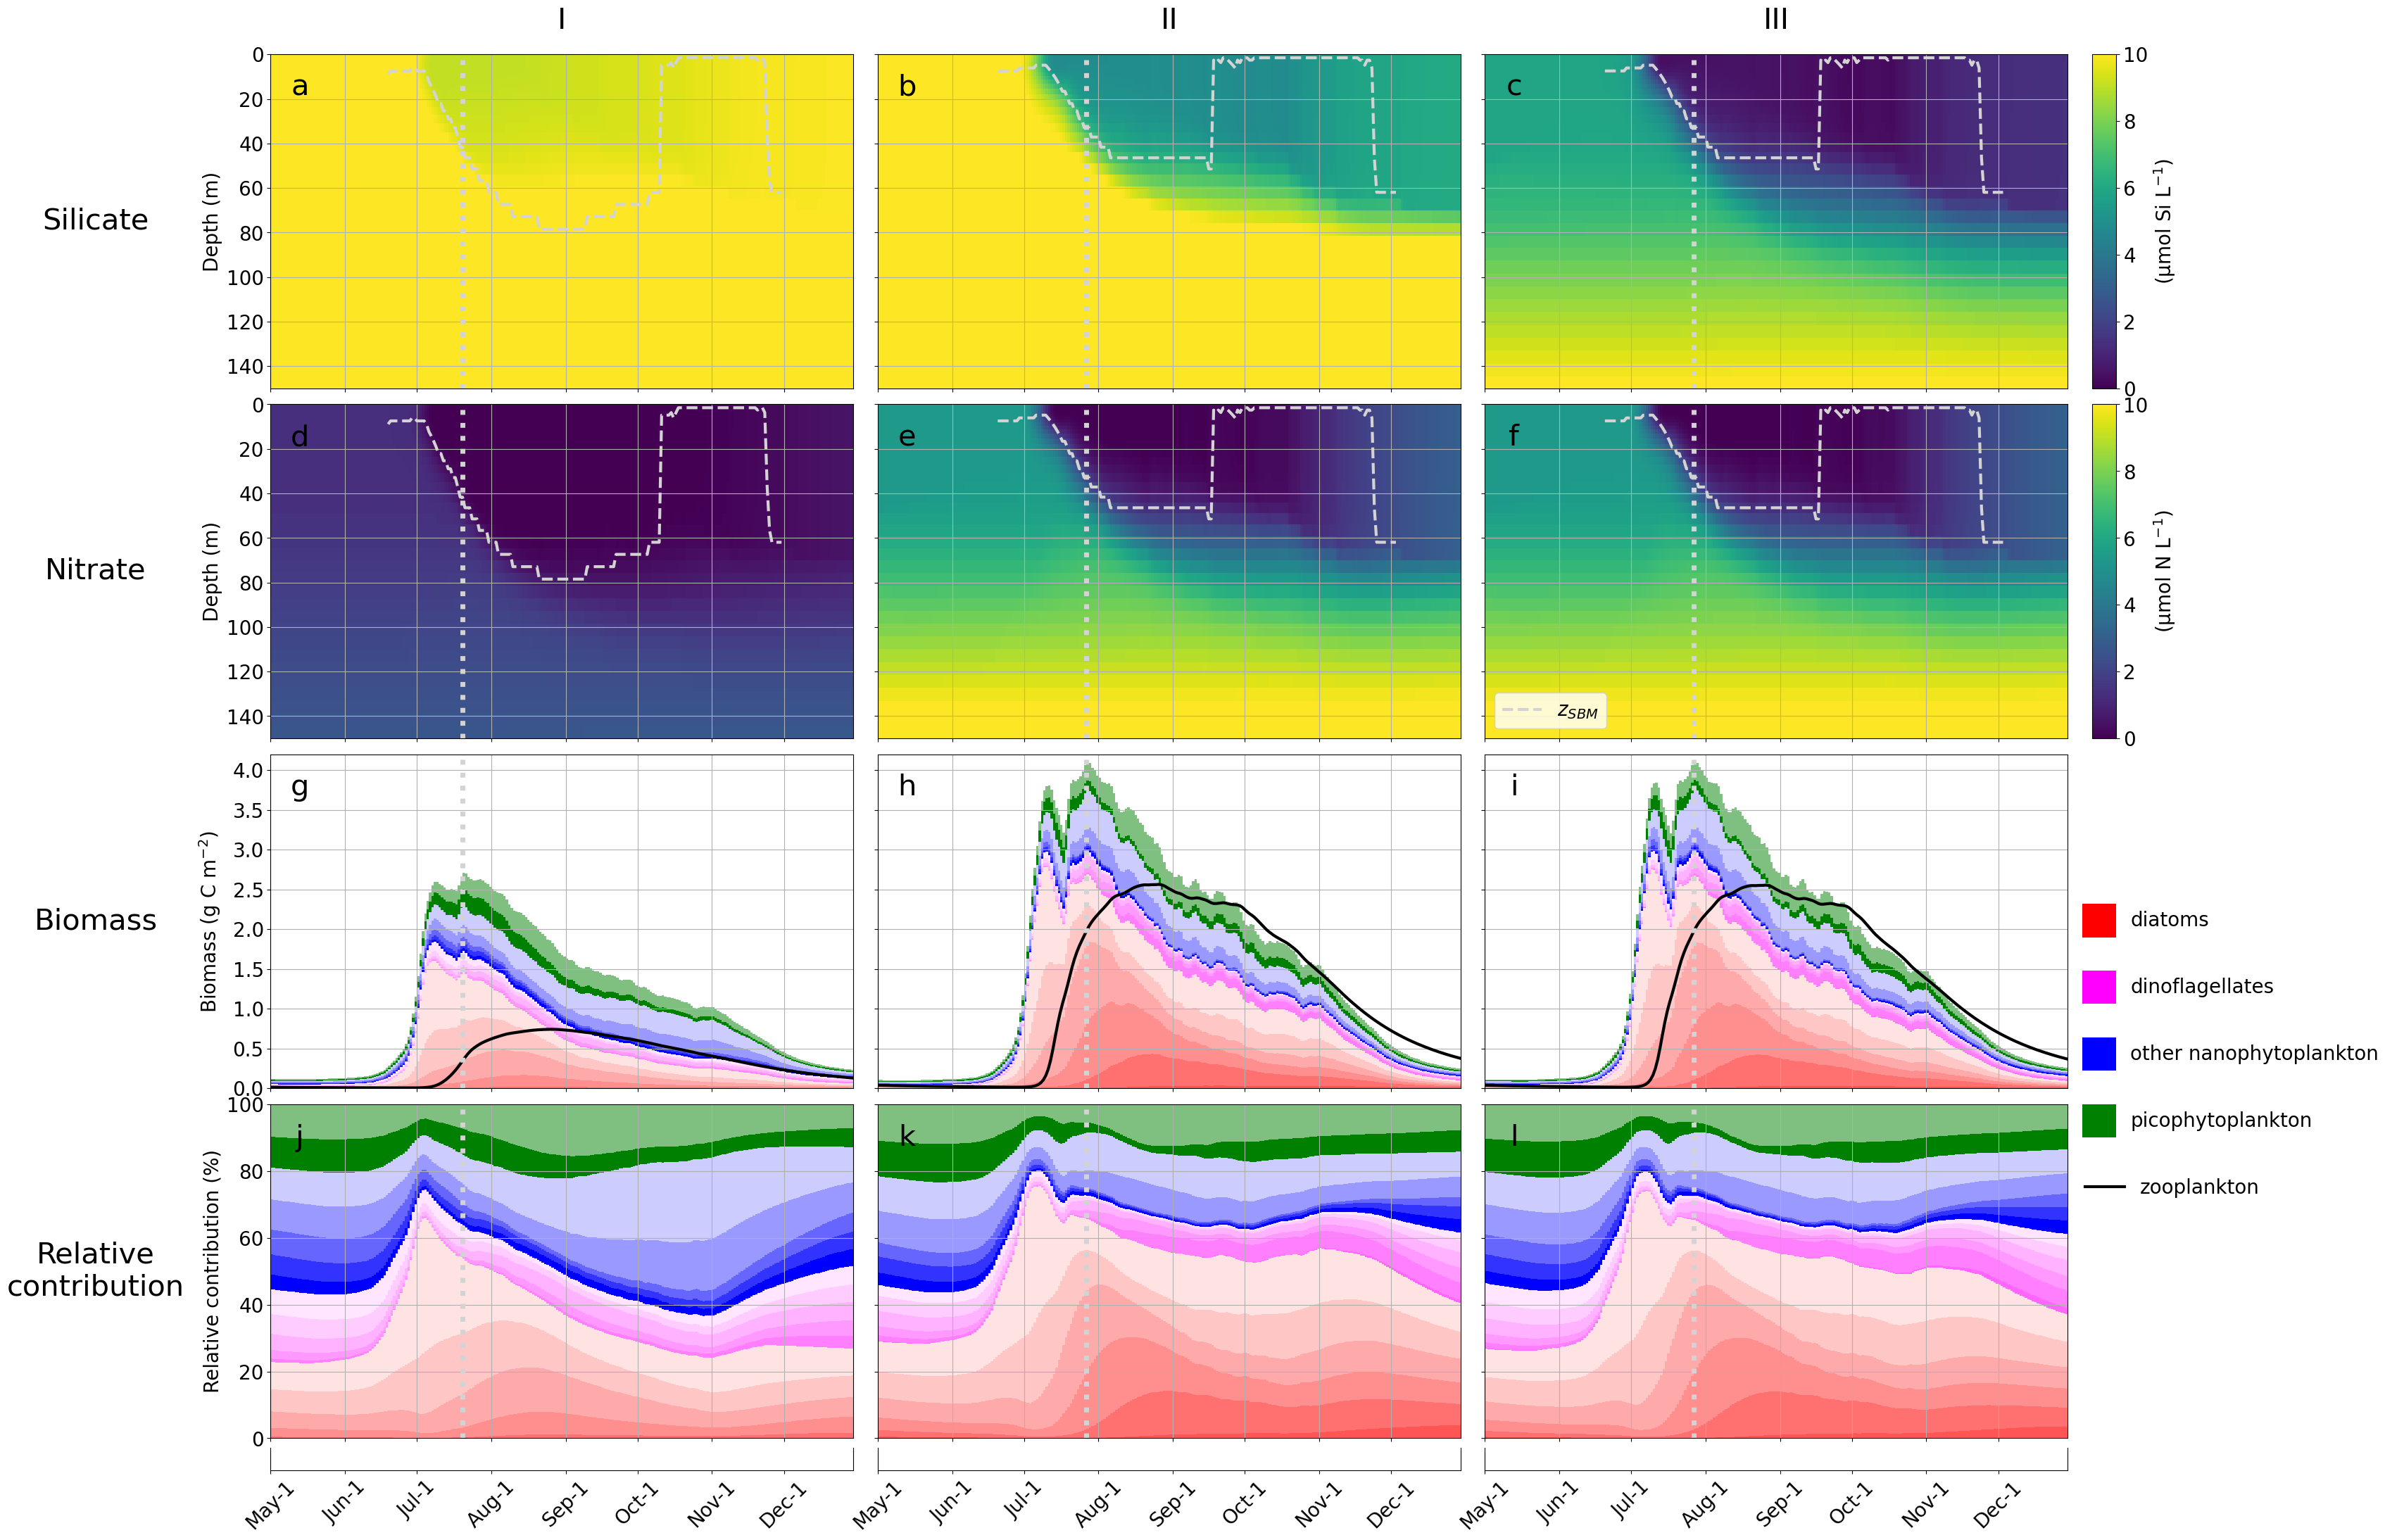

In [112]:
def make_plots(axs):
    locs=np.array([121, 152,
              182, 213, 244, 274, 305, 335])
    labels=('May-1','Jun-1',
            'Jul-1','Aug-1','Sep-1','Oct-1','Nov-1','Dec-1')
    xmin=first_year_from_may1[0]
    xmax=first_year_from_may1[-1]
    xlims=(xmin,xmax)
    
    # --- (A) SILICATE FOR EXP-S14N02 IN DOMAIN I
    ylims=(150,0)
    ax=axs[0,0]
    h=ax.pcolormesh(first_year366_from_may1,
                    RF_above151,
                    array2d_idepth_iT_modsioh4_s14n02[0:(RF_above151.size)-1,
                                                      first_year_from_may1],
                    vmin=0,
                    vmax=10)
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels([])
    ax.set_ylim(ylims)
    ax.set_ylabel('Depth (m)')
    ax.grid()
    
    # --- SUBSURFACE BIOMASS MAXIMUM FOR AUTOTROPHS AND MIXOTROPHS
    h=ax.plot(first_year,
              array1d_iT_zSBMautomixo_s14n02,
              color='lightgrey',linestyle='--',label='$z_{SBM}$')
    
    # --- DATE OF THE BIOMASS BLOOM PEAK
    ax.axvline(peak_s14n02,
               color='lightgrey',linestyle=':',linewidth=5)
    
    plt.text(0.05,0.90,'a',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes)
    plt.text(0.50,1.10,'I',
             horizontalalignment='center',verticalalignment='center',
             transform=ax.transAxes)
    plt.text(-0.30,0.50,'Silicate',
             horizontalalignment='center',verticalalignment='center',
             transform=ax.transAxes)
    
    # --- (B) SILICATE FOR EXP-S14N08 IN DOMAIN II
    ax=axs[0,1]
    h=ax.pcolormesh(first_year366_from_may1,
                    RF_above151,
                    array2d_idepth_iT_modsioh4_s14n08[0:(RF_above151.size)-1,
                                                      first_year_from_may1],
                    vmin=0,
                    vmax=10)
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels([])
    ax.set_ylim(ylims)
    ax.set_yticklabels([])
    ax.grid()
    
    # --- SUBSURFACE BIOMASS MAXIMUM FOR AUTOTROPHS AND MIXOTROPHS
    h=ax.plot(first_year,
              array1d_iT_zSBMautomixo_s14n08,
              color='lightgrey',linestyle='--',label='$z_{SBM}$')
    
    # --- DATE OF THE BIOMASS BLOOM PEAK
    ax.axvline(peak_s14n08,
               color='lightgrey',linestyle=':',linewidth=5)
    
    plt.text(0.05,0.90,'b',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes)
    plt.text(0.50,1.10,'II',
             horizontalalignment='center',verticalalignment='center',
             transform=ax.transAxes)
    
    # --- (C) SILICATE FOR EXP-S08N08 IN DOMAIN III
    ax=axs[0,2]
    h=ax.pcolormesh(first_year366_from_may1,
                    RF_above151,
                    array2d_idepth_iT_modsioh4_s08n08[0:(RF_above151.size)-1,
                                                      first_year_from_may1],
                    vmin=0,
                    vmax=10)
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels([])
    ax.set_ylim(ylims)
    ax.set_yticklabels([])
    ax.grid()
    
    cbaxes = fig.add_axes([0.87,0.73, 0.01,0.21])
    cbar=plt.colorbar(h,cax = cbaxes)
    cbar.set_label('($\mathrm{ \mu mol\ Si\ L^{-1} }$)')
    
    # --- SUBSURFACE BIOMASS MAXIMUM FOR AUTOTROPHS AND MIXOTROPHS
    h=ax.plot(first_year,
              array1d_iT_zSBMautomixo_s08n08,
              color='lightgrey',linestyle='--',label='$z_{SBM}$')
    
    # --- DATE OF THE BIOMASS BLOOM PEAK
    ax.axvline(peak_s08n08,
               color='lightgrey',linestyle=':',linewidth=5)
    
    plt.text(0.05,0.90,'c',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes)
    plt.text(0.50,1.10,'III',
             horizontalalignment='center',verticalalignment='center',
             transform=ax.transAxes)
    
    # --- (D) NITRATE FOR EXP-S14N02 IN DOMAIN I
    ax=axs[1,0]
    h=ax.pcolormesh(first_year366_from_may1,
                    RF_above151,
                    array2d_idepth_iT_modno3_s14n02[0:(RF_above151.size)-1,
                                                    first_year_from_may1],
                    vmin=0,
                    vmax=10)
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels([])
    ax.set_ylim(ylims)
    ax.set_ylabel('Depth (m)')
    ax.grid()
    
    # --- SUBSURFACE BIOMASS MAXIMUM FOR AUTOTROPHS AND MIXOTROPHS
    h=ax.plot(first_year,
              array1d_iT_zSBMautomixo_s14n02,
              color='lightgrey',linestyle='--',label='$z_{SBM}$')
    
    # --- DATE OF THE BIOMASS BLOOM PEAK
    ax.axvline(peak_s14n02,
               color='lightgrey',linestyle=':',linewidth=5)
    
    plt.text(0.05,0.90,'d',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes)
    plt.text(-0.30,0.50,'Nitrate',
             horizontalalignment='center',verticalalignment='center',
             transform=ax.transAxes)
    
    # --- (E) NITRATE FOR EXP-S14N08 IN DOMAIN II
    ax=axs[1,1]
    h=ax.pcolormesh(first_year366_from_may1,
                    RF_above151,
                    array2d_idepth_iT_modno3_s14n08[0:(RF_above151.size)-1,
                                                    first_year_from_may1],
                    vmin=0,
                    vmax=10)
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels([])
    ax.set_ylim(ylims)
    ax.set_yticklabels([])
    ax.grid()
    
    # --- SUBSURFACE BIOMASS MAXIMUM FOR AUTOTROPHS AND MIXOTROPHS
    h=ax.plot(first_year,
              array1d_iT_zSBMautomixo_s14n08,
              color='lightgrey',linestyle='--',label='$z_{SBM}$')
    
    # --- DATE OF THE BIOMASS BLOOM PEAK
    ax.axvline(peak_s14n08,
               color='lightgrey',linestyle=':',linewidth=5)
    
    plt.text(0.05,0.90,'e',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes)
    
    # --- (F) NITRATE FOR EXP-S08N08 IN DOMAIN III
    ax=axs[1,2]
    h=ax.pcolormesh(first_year366_from_may1,
                    RF_above151,
                    array2d_idepth_iT_modno3_s08n08[0:(RF_above151.size)-1,
                                                    first_year_from_may1],
                    vmin=0,
                    vmax=10)
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels([])
    ax.set_ylim(ylims)
    ax.set_yticklabels([])
    ax.grid()
    
    cbaxes = fig.add_axes([0.87,0.51, 0.01,0.21])
    cbar=plt.colorbar(h,cax = cbaxes)
    cbar.set_label('($\mathrm{ \mu mol\ N\ L^{-1} }$)')
    
    # --- SUBSURFACE BIOMASS MAXIMUM FOR AUTOTROPHS AND MIXOTROPHS
    h=ax.plot(first_year,
              array1d_iT_zSBMautomixo_s08n08,
              color='lightgrey',linestyle='--',label='$z_{SBM}$')
    ax.legend()
    
    # --- DATE OF THE BIOMASS BLOOM PEAK
    ax.axvline(peak_s08n08,
               color='lightgrey',linestyle=':',linewidth=5)
    
    plt.text(0.05,0.90,'f',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes)
    
    # --- (G) BIOMASS FOR EXP-S14N02 IN DOMAIN I
    ylims=(0,4.2)
    ax=axs[2,0]
    
    # --- BIOMASS OF AUTOTROPHS + MIXOTROPHS
    for iT in range(xmin,xmax+1):
        array1d_ip_sumc=array2d_ip_iT_sumc_s14n02[:,iT]
        for ip_automixo,ip in enumerate(ip_automixo_list):
            xmintemp=iT
            ymintemp=0
            if ip_automixo!=0:
                ymintemp=np.sum(array1d_ip_sumc[ip_automixo_list[0:ip_automixo]])
            width=1
            height=array1d_ip_sumc[ip]
            cxx=ip+1
            group_name,size_name=plankpy.Plankton.get_group_size(cxx)
            facecolor='black'
            if group_name=='pico':
                facecolor='green'
            elif group_name=='other':
                facecolor='blue'
            elif group_name=='diatoms':
                facecolor='red'
            elif group_name=='dino':
                facecolor='magenta'
            # isize_per_group is 0-based
            isize_per_group=plankpy.Plankton.get_isize_per_group(cxx)
            nsize_per_group= \
            plankpy.Plankton.get_nsize_per_group(group_name)
            alpha=(isize_per_group+1)/nsize_per_group
            rect=mpl.patches.Rectangle(
                xy=(xmintemp,ymintemp),
                width=width,
                height=height,
                linewidth=0,
                facecolor=facecolor,
                alpha=alpha)
            ax.add_patch(rect)
            
    # --- BIOMASS OF ZOO
    ax.plot(first_year,
            array1d_iT_sumczoo_s14n02,
            '-',color='black',label='zoo')
    
    # --- DATE OF THE BIOMASS BLOOM PEAK
    ax.axvline(peak_s14n02,
               color='lightgrey',linestyle=':',linewidth=5)
    
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels([])
    ax.set_ylim(ylims)
    ax.set_ylabel('Biomass ($\mathrm{ g\ C\ m^{-2} }$)')
    ax.grid()
    
    plt.text(0.05,0.90,'g',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes)
    plt.text(-0.30,0.50,'Biomass',
             horizontalalignment='center',verticalalignment='center',
             transform=ax.transAxes)
    
    # --- (H) BIOMASS FOR EXP-S14N08 IN DOMAIN II
    ax=axs[2,1]
    
    # --- BIOMASS OF AUTOTROPHS + MIXOTROPHS
    for iT in range(xmin,xmax+1):
        array1d_ip_sumc=array2d_ip_iT_sumc_s14n08[:,iT]
        for ip_automixo,ip in enumerate(ip_automixo_list):
            xmintemp=iT
            ymintemp=0
            if ip_automixo!=0:
                ymintemp=np.sum(array1d_ip_sumc[ip_automixo_list[0:ip_automixo]])
            width=1
            height=array1d_ip_sumc[ip]
            cxx=ip+1
            group_name,size_name=plankpy.Plankton.get_group_size(cxx)
            facecolor='black'
            if group_name=='pico':
                facecolor='green'
            elif group_name=='other':
                facecolor='blue'
            elif group_name=='diatoms':
                facecolor='red'
            elif group_name=='dino':
                facecolor='magenta'
            # isize_per_group is 0-based
            isize_per_group=plankpy.Plankton.get_isize_per_group(cxx)
            nsize_per_group= \
            plankpy.Plankton.get_nsize_per_group(group_name)
            alpha=(isize_per_group+1)/nsize_per_group
            rect=mpl.patches.Rectangle(
                xy=(xmintemp,ymintemp),
                width=width,
                height=height,
                linewidth=0,
                facecolor=facecolor,
                alpha=alpha)
            ax.add_patch(rect)
            
    # --- BIOMASS OF ZOO
    ax.plot(first_year,
            array1d_iT_sumczoo_s14n08,
            '-',color='black',label='zoo')
    
    # --- DATE OF THE BIOMASS BLOOM PEAK
    ax.axvline(peak_s14n08,
               color='lightgrey',linestyle=':',linewidth=5)
    
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels([])
    ax.set_ylim(ylims)
    ax.set_yticklabels([])
    ax.grid()
    
    plt.text(0.05,0.90,'h',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes)
    
    # --- (I) BIOMASS FOR EXP-S18N08 IN DOMAIN III
    ax=axs[2,2]
    
    # --- BIOMASS OF AUTOTROPHS + MIXOTROPHS
    for iT in range(xmin,xmax+1):
        array1d_ip_sumc=array2d_ip_iT_sumc_s08n08[:,iT]
        for ip_automixo,ip in enumerate(ip_automixo_list):
            xmintemp=iT
            ymintemp=0
            if ip_automixo!=0:
                ymintemp=np.sum(array1d_ip_sumc[ip_automixo_list[0:ip_automixo]])
            width=1
            height=array1d_ip_sumc[ip]
            cxx=ip+1
            group_name,size_name=plankpy.Plankton.get_group_size(cxx)
            facecolor='black'
            if group_name=='pico':
                facecolor='green'
            elif group_name=='other':
                facecolor='blue'
            elif group_name=='diatoms':
                facecolor='red'
            elif group_name=='dino':
                facecolor='magenta'
            # isize_per_group is 0-based
            isize_per_group=plankpy.Plankton.get_isize_per_group(cxx)
            nsize_per_group= \
            plankpy.Plankton.get_nsize_per_group(group_name)
            alpha=(isize_per_group+1)/nsize_per_group
            rect=mpl.patches.Rectangle(
                xy=(xmintemp,ymintemp),
                width=width,
                height=height,
                linewidth=0,
                facecolor=facecolor,
                alpha=alpha)
            ax.add_patch(rect)
            
    # --- BIOMASS OF ZOO
    ax.plot(first_year,
            array1d_iT_sumczoo_s08n08,
            '-',color='black',label='zooplankton')
    ax.legend(loc='lower left',
              frameon=False,
              bbox_to_anchor=(1.00,-0.38))
    
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels([])
    ax.set_ylim(ylims)
    ax.set_yticklabels([])
    ax.grid()
    
    # --- DATE OF THE BIOMASS BLOOM PEAK
    ax.axvline(peak_s08n08,
               color='lightgrey',linestyle=':',linewidth=5)
    
    plt.text(0.05,0.90,'i',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes)
    
    # --- (J) RELATIVE CONTRIBUTION FOR EXP-S14N02 IN DOMAIN I
    ylims=(0,100)
    ax=axs[3,0]
    
    # --- RELATIVE CONTRIBUTION TO AUTOTROPHS + MIXOTROPHS
    for iT in range(xmin,xmax+1):
        array1d_ip_perc=array2d_ip_iT_perc_s14n02[:,iT]
        for ip_automixo,ip in enumerate(ip_automixo_list):
            xmintemp=iT
            ymintemp=0
            if ip_automixo!=0:
                ymintemp=np.sum(array1d_ip_perc[ip_automixo_list[0:ip_automixo]])
            width=1
            height=array1d_ip_perc[ip]
            cxx=ip+1
            group_name,size_name=plankpy.Plankton.get_group_size(cxx)
            facecolor='black'
            if group_name=='pico':
                facecolor='green'
            elif group_name=='other':
                facecolor='blue'
            elif group_name=='diatoms':
                facecolor='red'
            elif group_name=='dino':
                facecolor='magenta'
            # isize_per_group is 0-based
            isize_per_group=plankpy.Plankton.get_isize_per_group(cxx)
            nsize_per_group= \
            plankpy.Plankton.get_nsize_per_group(group_name)
            alpha=(isize_per_group+1)/nsize_per_group
            rect=mpl.patches.Rectangle(
                xy=(xmintemp,ymintemp),
                width=width,
                height=height,
                linewidth=0,
                facecolor=facecolor,
                alpha=alpha)
            ax.add_patch(rect)
    
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels([])
    ax.set_ylim(ylims)
    ax.set_ylabel('Relative contribution (%)')
    ax.grid()
    
    # --- DATE OF THE BIOMASS BLOOM PEAK
    ax.axvline(peak_s14n02,
               color='lightgrey',linestyle=':',linewidth=5)
    
    plt.text(0.05,0.90,'j',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes)
    plt.text(-0.30,0.50,'Relative\ncontribution',
             fontsize=30,
             horizontalalignment='center',verticalalignment='center',
             transform=ax.transAxes)
    
    # --- (K) RELATIVE CONTRIBUTION FOR EXP-S14N08 IN DOMAIN II
    ylims=(0,100)
    ax=axs[3,1]
    
    # --- RELATIVE CONTRIBUTION TO AUTOTROPHS + MIXOTROPHS
    for iT in range(xmin,xmax+1):
        array1d_ip_perc=array2d_ip_iT_perc_s14n08[:,iT]
        for ip_automixo,ip in enumerate(ip_automixo_list):
            xmintemp=iT
            ymintemp=0
            if ip_automixo!=0:
                ymintemp=np.sum(array1d_ip_perc[ip_automixo_list[0:ip_automixo]])
            width=1
            height=array1d_ip_perc[ip]
            cxx=ip+1
            group_name,size_name=plankpy.Plankton.get_group_size(cxx)
            facecolor='black'
            if group_name=='pico':
                facecolor='green'
            elif group_name=='other':
                facecolor='blue'
            elif group_name=='diatoms':
                facecolor='red'
            elif group_name=='dino':
                facecolor='magenta'
            # isize_per_group is 0-based
            isize_per_group=plankpy.Plankton.get_isize_per_group(cxx)
            nsize_per_group= \
            plankpy.Plankton.get_nsize_per_group(group_name)
            alpha=(isize_per_group+1)/nsize_per_group
            rect=mpl.patches.Rectangle(
                xy=(xmintemp,ymintemp),
                width=width,
                height=height,
                linewidth=0,
                facecolor=facecolor,
                alpha=alpha)
            ax.add_patch(rect)
    
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels([])
    ax.set_ylim(ylims)
    ax.set_yticklabels([])
    ax.grid()
    
    # --- DATE OF THE BIOMASS BLOOM PEAK
    ax.axvline(peak_s14n08,
               color='lightgrey',linestyle=':',linewidth=5)
    
    plt.text(0.05,0.90,'k',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes)
    
    # --- (L) RELATIVE CONTRIBUTION FOR EXP-S08N08 IN DOMAIN III
    ylims=(0,100)
    ax=axs[3,2]
    
    # --- RELATIVE CONTRIBUTION TO AUTOTROPHS + MIXOTROPHS
    for iT in range(xmin,xmax+1):
        array1d_ip_perc=array2d_ip_iT_perc_s08n08[:,iT]
        for ip_automixo,ip in enumerate(ip_automixo_list):
            xmintemp=iT
            ymintemp=0
            if ip_automixo!=0:
                ymintemp=np.sum(array1d_ip_perc[ip_automixo_list[0:ip_automixo]])
            width=1
            height=array1d_ip_perc[ip]
            cxx=ip+1
            group_name,size_name=plankpy.Plankton.get_group_size(cxx)
            facecolor='black'
            if group_name=='pico':
                facecolor='green'
            elif group_name=='other':
                facecolor='blue'
            elif group_name=='diatoms':
                facecolor='red'
            elif group_name=='dino':
                facecolor='magenta'
            # isize_per_group is 0-based
            isize_per_group=plankpy.Plankton.get_isize_per_group(cxx)
            nsize_per_group= \
            plankpy.Plankton.get_nsize_per_group(group_name)
            alpha=(isize_per_group+1)/nsize_per_group
            rect=mpl.patches.Rectangle(
                xy=(xmintemp,ymintemp),
                width=width,
                height=height,
                linewidth=0,
                facecolor=facecolor,
                alpha=alpha)
            ax.add_patch(rect)
            
    # --- LEGEND
    # diatoms
    rect=mpl.patches.Rectangle(
        xy=(370,150),
        width=14,
        height=10,
        linewidth=0,
        facecolor='red',
        clip_on=False)
    ax.add_patch(rect)
    plt.text(390,155,'diatoms',
             fontsize=20,
             horizontalalignment = 'left',verticalalignment='center',
             transform=ax.transData)
    # dino
    rect=mpl.patches.Rectangle(
        xy=(370,130),
        width=14,
        height=10,
        linewidth=0,
        facecolor='magenta',
        clip_on=False)
    ax.add_patch(rect)
    plt.text(390,135,'dinoflagellates',
             fontsize=20,
             horizontalalignment = 'left',verticalalignment='center',
             transform=ax.transData)
    # other
    rect=mpl.patches.Rectangle(
        xy=(370,110),
        width=14,
        height=10,
        linewidth=0,
        facecolor='blue',
        clip_on=False)
    ax.add_patch(rect)
    plt.text(390,115,'other nanophytoplankton',
             fontsize=20,
             horizontalalignment = 'left',verticalalignment='center',
             transform=ax.transData)
    # pico
    rect=mpl.patches.Rectangle(
        xy=(370,90),
        width=14,
        height=10,
        linewidth=0,
        facecolor='green',
        clip_on=False)
    ax.add_patch(rect)
    plt.text(390,95,'picophytoplankton',
             fontsize=20,
             horizontalalignment = 'left',verticalalignment='center',
             transform=ax.transData)
    
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels([])
    ax.set_ylim(ylims)
    ax.set_yticklabels([])
    ax.grid()
    
    # --- DATE OF THE BIOMASS BLOOM PEAK
    ax.axvline(peak_s08n08,
               color='lightgrey',linestyle=':',linewidth=5)
    
    plt.text(0.05,0.90,'l',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes)
    
    # --- ADDITIONAL X-AXIS
    ax=axs[4,0]
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels(labels,rotation=45)
    ax.axes.get_yaxis().set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # --- ADDITIONAL X-AXIS
    ax=axs[4,1]
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels(labels,rotation=45)
    ax.axes.get_yaxis().set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # --- ADDITIONAL X-AXIS
    ax=axs[4,2]
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels(labels,rotation=45)
    ax.axes.get_yaxis().set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # --- POSITION
    axs[0,0].set_position([0.12,0.73, 0.24,0.21])
    axs[0,1].set_position([0.37,0.73, 0.24,0.21])
    axs[0,2].set_position([0.62,0.73, 0.24,0.21])
    axs[1,0].set_position([0.12,0.51, 0.24,0.21])
    axs[1,1].set_position([0.37,0.51, 0.24,0.21])
    axs[1,2].set_position([0.62,0.51, 0.24,0.21])
    axs[2,0].set_position([0.12,0.29, 0.24,0.21])
    axs[2,1].set_position([0.37,0.29, 0.24,0.21])
    axs[2,2].set_position([0.62,0.29, 0.24,0.21])
    axs[3,0].set_position([0.12,0.07, 0.24,0.21])
    axs[3,1].set_position([0.37,0.07, 0.24,0.21])
    axs[3,2].set_position([0.62,0.07, 0.24,0.21])
    axs[4,0].set_position([0.12,0.05, 0.24,0.014])
    axs[4,1].set_position([0.37,0.05, 0.24,0.014])
    axs[4,2].set_position([0.62,0.05, 0.24,0.014])

with plt.style.context('mplstyles/plots_domains.mplstyle'):
    # Plot
    fig,axs=plt.subplots(nrows=5,ncols=3,figsize=(34.50,22.60))
    make_plots(axs)
    fig.align_ylabels(axs[:,0])

    # --- SAVE
    outfile='figures/figure4.'+ext
    plt.savefig(outfile,dpi=dpi)

**Figure <plots.I.II.III>**.
**Model output for the main simulations in domains I, II and III.**
Table <tab:sims> (in https://www.overleaf.com/read/pnjkspdjccsb#37939f) presents the sample simulations for each domain.
**(a)** Silicate for EXP-S14N02 in domain I.
**(b)** Silicate for EXP-S14N08 in domain II.
**(c)** Silicate for EXP-S08N08 in domain III.
**(d)** Nitrate  for EXP-S14N02 in domain I.
**(e)** Nitrate  for EXP-S14N08 in domain II.
**(f)** Nitrate  for EXP-S08N08 in domain III.
**(g)** Biomass for each phytoplankton type for EXP-S14N02 in domain I.
**(h)** Biomass for each phytoplankton type for EXP-S14N08 in domain II.
**(i)** Biomass for each phytoplankton type for EXP-S08N08 in domain III.
**(j)** Relative contribution for each phytoplankton type for EXP-S14N02 in domain I.
**(k)** Relative contribution for each phytoplankton type for EXP-S14N08 in domain II.
**(l)** Relative contribution for each phytoplankton type for EXP-S08N08 in domain III.
The subsurface biomass maximum is a grey dashed line.
The biomass of total zooplankton is a black line.
The vertical grey dotted line is the date of the bloom peak (based on biomass).

# Plot main experiments for nutrient regimes IV, V and VI

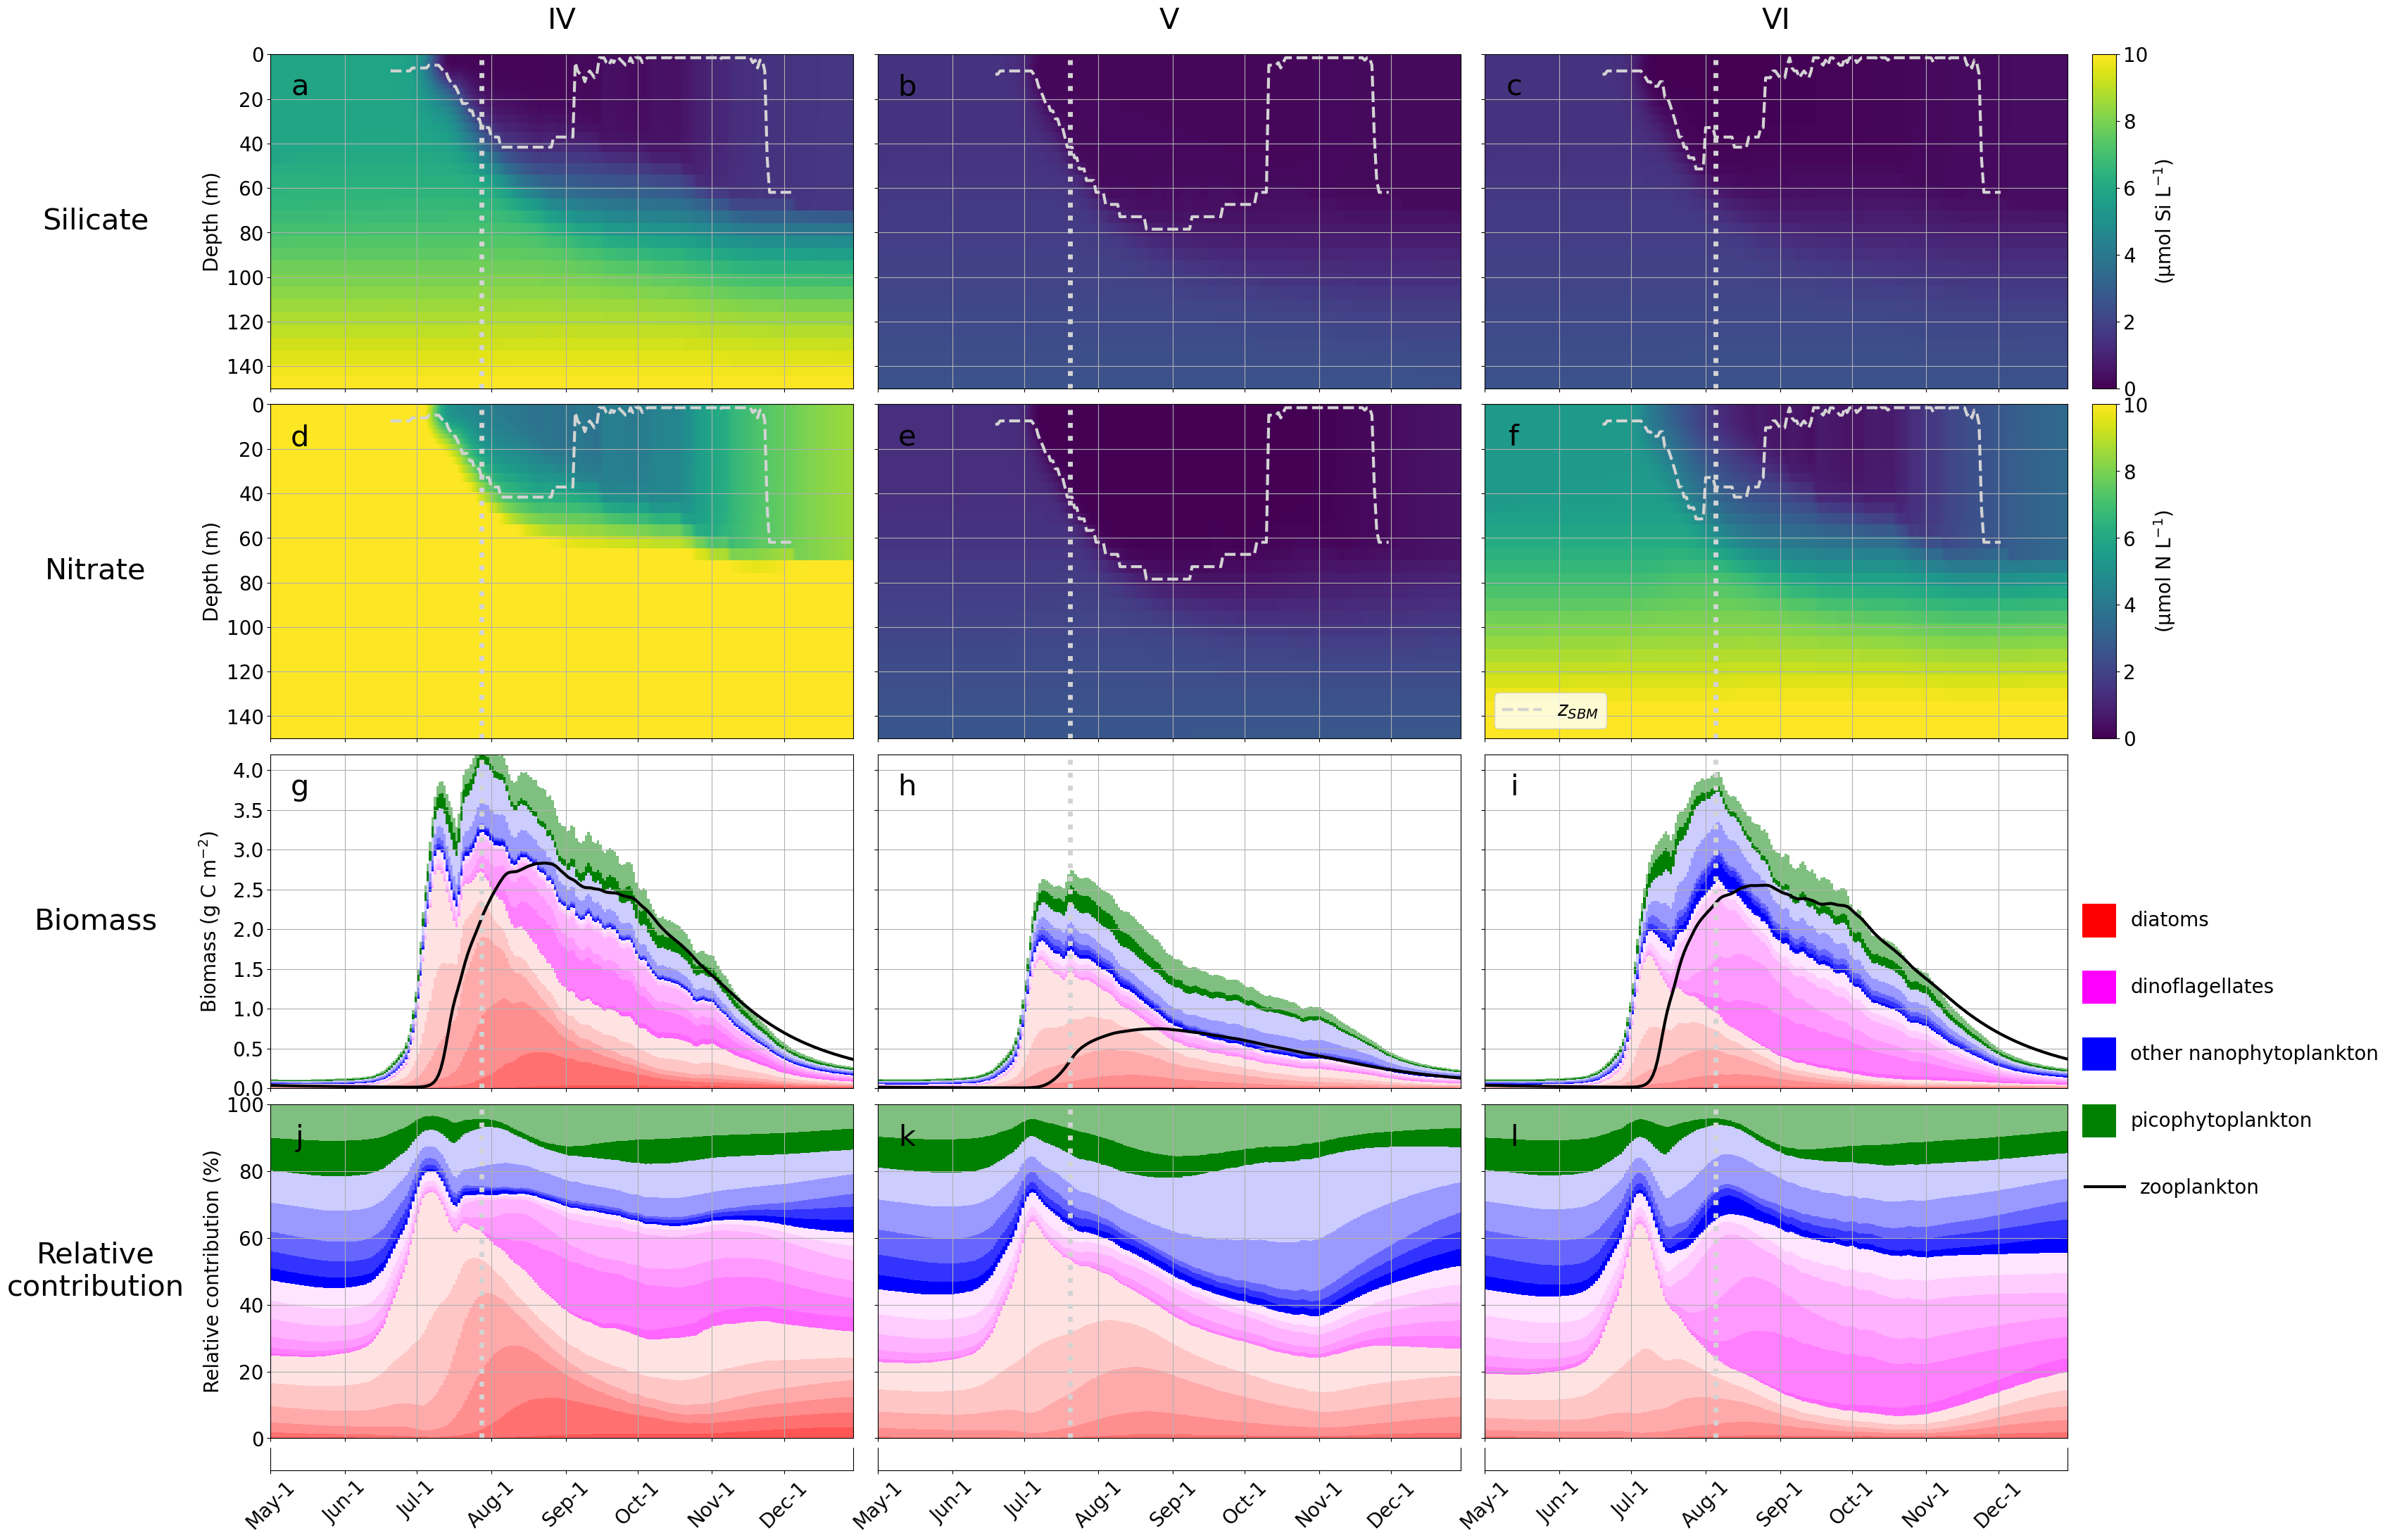

In [113]:
def make_plots(axs):
    locs=np.array([121, 152,
              182, 213, 244, 274, 305, 335])
    labels=('May-1','Jun-1',
            'Jul-1','Aug-1','Sep-1','Oct-1','Nov-1','Dec-1')
    xmin=first_year_from_may1[0]
    xmax=first_year_from_may1[-1]
    xlims=(xmin,xmax)
    
    # --- (A) SILICATE FOR EXP-S08N16 IN DOMAIN IV
    ylims=(150,0)
    ax=axs[0,0]
    h=ax.pcolormesh(first_year366_from_may1,
                    RF_above151,
                    array2d_idepth_iT_modsioh4_s08n16[0:(RF_above151.size)-1,
                                                      first_year_from_may1],
                    vmin=0,
                    vmax=10)
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels([])
    ax.set_ylim(ylims)
    ax.set_ylabel('Depth (m)')
    ax.grid()
    
    # --- SUBSURFACE BIOMASS MAXIMUM FOR AUTOTROPHS AND MIXOTROPHS
    h=ax.plot(first_year,
              array1d_iT_zSBMautomixo_s08n16,
              color='lightgrey',linestyle='--',label='$z_{SBM}$')
    
    # --- DATE OF THE BIOMASS BLOOM PEAK
    ax.axvline(peak_s08n16,
               color='lightgrey',linestyle=':',linewidth=5)
    
    plt.text(0.05,0.90,'a',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes)
    plt.text(0.50,1.10,'IV',
             horizontalalignment='center',verticalalignment='center',
             transform=ax.transAxes)
    plt.text(-0.30,0.50,'Silicate',
             horizontalalignment='center',verticalalignment='center',
             transform=ax.transAxes)
    
    # --- (B) SILICATE FOR EXP-S02N02 IN DOMAIN V
    ax=axs[0,1]
    h=ax.pcolormesh(first_year366_from_may1,
                    RF_above151,
                    array2d_idepth_iT_modsioh4_s02n02[0:(RF_above151.size)-1,
                                                      first_year_from_may1],
                    vmin=0,
                    vmax=10)
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels([])
    ax.set_ylim(ylims)
    ax.set_yticklabels([])
    ax.grid()
    
    # --- SUBSURFACE BIOMASS MAXIMUM FOR AUTOTROPHS AND MIXOTROPHS
    h=ax.plot(first_year,
              array1d_iT_zSBMautomixo_s02n02,
              color='lightgrey',linestyle='--',label='$z_{SBM}$')
    
    # --- DATE OF THE BIOMASS BLOOM PEAK
    ax.axvline(peak_s02n02,
               color='lightgrey',linestyle=':',linewidth=5)
    
    plt.text(0.05,0.90,'b',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes)
    plt.text(0.50,1.10,'V',
             horizontalalignment='center',verticalalignment='center',
             transform=ax.transAxes)
    
    # --- (C) SILICATE FOR EXP-S02N08 IN DOMAIN VI
    ax=axs[0,2]
    h=ax.pcolormesh(first_year366_from_may1,
                    RF_above151,
                    array2d_idepth_iT_modsioh4_s02n08[0:(RF_above151.size)-1,
                                                      first_year_from_may1],
                    vmin=0,
                    vmax=10)
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels([])
    ax.set_ylim(ylims)
    ax.set_yticklabels([])
    ax.grid()
    
    cbaxes = fig.add_axes([0.87,0.73, 0.01,0.21])
    cbar=plt.colorbar(h,cax = cbaxes)
    cbar.set_label('($\mathrm{ \mu mol\ Si\ L^{-1} }$)')
    
    # --- SUBSURFACE BIOMASS MAXIMUM FOR AUTOTROPHS AND MIXOTROPHS
    h=ax.plot(first_year,
              array1d_iT_zSBMautomixo_s02n08,
              color='lightgrey',linestyle='--',label='$z_{SBM}$')
    
    # --- DATE OF THE BIOMASS BLOOM PEAK
    ax.axvline(peak_s02n08,
               color='lightgrey',linestyle=':',linewidth=5)
    
    plt.text(0.05,0.90,'c',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes)
    plt.text(0.50,1.10,'VI',
             horizontalalignment='center',verticalalignment='center',
             transform=ax.transAxes)
    
    # --- (D) NITRATE FOR EXP-S08N16 IN DOMAIN IV
    ax=axs[1,0]
    h=ax.pcolormesh(first_year366_from_may1,
                    RF_above151,
                    array2d_idepth_iT_modno3_s08n16[0:(RF_above151.size)-1,
                                                    first_year_from_may1],
                    vmin=0,
                    vmax=10)
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels([])
    ax.set_ylim(ylims)
    ax.set_ylabel('Depth (m)')
    ax.grid()
    
    # --- SUBSURFACE BIOMASS MAXIMUM FOR AUTOTROPHS AND MIXOTROPHS
    h=ax.plot(first_year,
              array1d_iT_zSBMautomixo_s08n16,
              color='lightgrey',linestyle='--',label='$z_{SBM}$')
    
    # --- DATE OF THE BIOMASS BLOOM PEAK
    ax.axvline(peak_s08n16,
               color='lightgrey',linestyle=':',linewidth=5)
    
    plt.text(0.05,0.90,'d',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes)
    plt.text(-0.30,0.50,'Nitrate',
             horizontalalignment='center',verticalalignment='center',
             transform=ax.transAxes)
    
    # --- (E) NITRATE FOR EXP-S02N02 IN DOMAIN V
    ax=axs[1,1]
    h=ax.pcolormesh(first_year366_from_may1,
                    RF_above151,
                    array2d_idepth_iT_modno3_s02n02[0:(RF_above151.size)-1,
                                                    first_year_from_may1],
                    vmin=0,
                    vmax=10)
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels([])
    ax.set_ylim(ylims)
    ax.set_yticklabels([])
    ax.grid()
    
    # --- SUBSURFACE BIOMASS MAXIMUM FOR AUTOTROPHS AND MIXOTROPHS
    h=ax.plot(first_year,
              array1d_iT_zSBMautomixo_s02n02,
              color='lightgrey',linestyle='--',label='$z_{SBM}$')
    
    # --- DATE OF THE BIOMASS BLOOM PEAK
    ax.axvline(peak_s02n02,
               color='lightgrey',linestyle=':',linewidth=5)
    
    plt.text(0.05,0.90,'e',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes)
    
    # --- (F) NITRATE FOR EXP-S02N08 IN DOMAIN VI
    ax=axs[1,2]
    h=ax.pcolormesh(first_year366_from_may1,
                    RF_above151,
                    array2d_idepth_iT_modno3_s02n08[0:(RF_above151.size)-1,
                                                    first_year_from_may1],
                    vmin=0,
                    vmax=10)
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels([])
    ax.set_ylim(ylims)
    ax.set_yticklabels([])
    ax.grid()
    
    cbaxes = fig.add_axes([0.87,0.51, 0.01,0.21])
    cbar=plt.colorbar(h,cax = cbaxes)
    cbar.set_label('($\mathrm{ \mu mol\ N\ L^{-1} }$)')
    
    # --- SUBSURFACE BIOMASS MAXIMUM FOR AUTOTROPHS AND MIXOTROPHS
    h=ax.plot(first_year,
              array1d_iT_zSBMautomixo_s02n08,
              color='lightgrey',linestyle='--',label='$z_{SBM}$')
    ax.legend()
    
    # --- DATE OF THE BIOMASS BLOOM PEAK
    ax.axvline(peak_s02n08,
               color='lightgrey',linestyle=':',linewidth=5)
    
    plt.text(0.05,0.90,'f',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes)
    
    # --- (G) BIOMASS FOR EXP-S08N16 IN DOMAIN IV
    ylims=(0,4.2)
    ax=axs[2,0]
    
    # --- BIOMASS OF AUTOTROPHS + MIXOTROPHS
    for iT in range(xmin,xmax+1):
        array1d_ip_sumc=array2d_ip_iT_sumc_s08n16[:,iT]
        for ip_automixo,ip in enumerate(ip_automixo_list):
            xmintemp=iT
            ymintemp=0
            if ip_automixo!=0:
                ymintemp=np.sum(array1d_ip_sumc[ip_automixo_list[0:ip_automixo]])
            width=1
            height=array1d_ip_sumc[ip]
            cxx=ip+1
            group_name,size_name=plankpy.Plankton.get_group_size(cxx)
            facecolor='black'
            if group_name=='pico':
                facecolor='green'
            elif group_name=='other':
                facecolor='blue'
            elif group_name=='diatoms':
                facecolor='red'
            elif group_name=='dino':
                facecolor='magenta'
            # isize_per_group is 0-based
            isize_per_group=plankpy.Plankton.get_isize_per_group(cxx)
            nsize_per_group= \
            plankpy.Plankton.get_nsize_per_group(group_name)
            alpha=(isize_per_group+1)/nsize_per_group
            rect=mpl.patches.Rectangle(
                xy=(xmintemp,ymintemp),
                width=width,
                height=height,
                linewidth=0,
                facecolor=facecolor,
                alpha=alpha)
            ax.add_patch(rect)
            
    # --- BIOMASS OF ZOO
    ax.plot(first_year,
            array1d_iT_sumczoo_s08n16,
            '-',color='black',label='zoo')
    
    # --- DATE OF THE BIOMASS BLOOM PEAK
    ax.axvline(peak_s08n16,
               color='lightgrey',linestyle=':',linewidth=5)
    
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels([])
    ax.set_ylim(ylims)
    ax.set_ylabel('Biomass ($\mathrm{ g\ C\ m^{-2} }$)')
    ax.grid()
    
    plt.text(0.05,0.90,'g',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes)
    plt.text(-0.30,0.50,'Biomass',
             horizontalalignment='center',verticalalignment='center',
             transform=ax.transAxes)
    
    # --- (H) BIOMASS FOR EXP-S02N02 IN DOMAIN V
    ax=axs[2,1]
    
    # --- BIOMASS OF AUTOTROPHS + MIXOTROPHS
    for iT in range(xmin,xmax+1):
        array1d_ip_sumc=array2d_ip_iT_sumc_s02n02[:,iT]
        for ip_automixo,ip in enumerate(ip_automixo_list):
            xmintemp=iT
            ymintemp=0
            if ip_automixo!=0:
                ymintemp=np.sum(array1d_ip_sumc[ip_automixo_list[0:ip_automixo]])
            width=1
            height=array1d_ip_sumc[ip]
            cxx=ip+1
            group_name,size_name=plankpy.Plankton.get_group_size(cxx)
            facecolor='black'
            if group_name=='pico':
                facecolor='green'
            elif group_name=='other':
                facecolor='blue'
            elif group_name=='diatoms':
                facecolor='red'
            elif group_name=='dino':
                facecolor='magenta'
            # isize_per_group is 0-based
            isize_per_group=plankpy.Plankton.get_isize_per_group(cxx)
            nsize_per_group= \
            plankpy.Plankton.get_nsize_per_group(group_name)
            alpha=(isize_per_group+1)/nsize_per_group
            rect=mpl.patches.Rectangle(
                xy=(xmintemp,ymintemp),
                width=width,
                height=height,
                linewidth=0,
                facecolor=facecolor,
                alpha=alpha)
            ax.add_patch(rect)
            
    # --- BIOMASS OF ZOO
    ax.plot(first_year,
            array1d_iT_sumczoo_s02n02,
            '-',color='black',label='zoo')
    
    # --- DATE OF THE BIOMASS BLOOM PEAK
    ax.axvline(peak_s02n02,
               color='lightgrey',linestyle=':',linewidth=5)
    
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels([])
    ax.set_ylim(ylims)
    ax.set_yticklabels([])
    ax.grid()
    
    plt.text(0.05,0.90,'h',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes)
    
    # --- (I) BIOMASS FOR EXP-S02N08 IN DOMAIN VI
    ax=axs[2,2]
    
    # --- BIOMASS OF AUTOTROPHS + MIXOTROPHS
    for iT in range(xmin,xmax+1):
        array1d_ip_sumc=array2d_ip_iT_sumc_s02n08[:,iT]
        for ip_automixo,ip in enumerate(ip_automixo_list):
            xmintemp=iT
            ymintemp=0
            if ip_automixo!=0:
                ymintemp=np.sum(array1d_ip_sumc[ip_automixo_list[0:ip_automixo]])
            width=1
            height=array1d_ip_sumc[ip]
            cxx=ip+1
            group_name,size_name=plankpy.Plankton.get_group_size(cxx)
            facecolor='black'
            if group_name=='pico':
                facecolor='green'
            elif group_name=='other':
                facecolor='blue'
            elif group_name=='diatoms':
                facecolor='red'
            elif group_name=='dino':
                facecolor='magenta'
            # isize_per_group is 0-based
            isize_per_group=plankpy.Plankton.get_isize_per_group(cxx)
            nsize_per_group= \
            plankpy.Plankton.get_nsize_per_group(group_name)
            alpha=(isize_per_group+1)/nsize_per_group
            rect=mpl.patches.Rectangle(
                xy=(xmintemp,ymintemp),
                width=width,
                height=height,
                linewidth=0,
                facecolor=facecolor,
                alpha=alpha)
            ax.add_patch(rect)
            
    # --- BIOMASS OF ZOO
    ax.plot(first_year,
            array1d_iT_sumczoo_s08n08,
            '-',color='black',label='zooplankton')
    ax.legend(loc='lower left',
              frameon=False,
              bbox_to_anchor=(1.00,-0.38))
    
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels([])
    ax.set_ylim(ylims)
    ax.set_yticklabels([])
    ax.grid()
    
    # --- DATE OF THE BIOMASS BLOOM PEAK
    ax.axvline(peak_s02n08,
               color='lightgrey',linestyle=':',linewidth=5)
    
    plt.text(0.05,0.90,'i',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes)
    
    # --- (J) RELATIVE CONTRIBUTION FOR EXP-S08N16 IN DOMAIN I
    ylims=(0,100)
    ax=axs[3,0]
    
    # --- RELATIVE CONTRIBUTION TO AUTOTROPHS + MIXOTROPHS
    for iT in range(xmin,xmax+1):
        array1d_ip_perc=array2d_ip_iT_perc_s08n16[:,iT]
        for ip_automixo,ip in enumerate(ip_automixo_list):
            xmintemp=iT
            ymintemp=0
            if ip_automixo!=0:
                ymintemp=np.sum(array1d_ip_perc[ip_automixo_list[0:ip_automixo]])
            width=1
            height=array1d_ip_perc[ip]
            cxx=ip+1
            group_name,size_name=plankpy.Plankton.get_group_size(cxx)
            facecolor='black'
            if group_name=='pico':
                facecolor='green'
            elif group_name=='other':
                facecolor='blue'
            elif group_name=='diatoms':
                facecolor='red'
            elif group_name=='dino':
                facecolor='magenta'
            # isize_per_group is 0-based
            isize_per_group=plankpy.Plankton.get_isize_per_group(cxx)
            nsize_per_group= \
            plankpy.Plankton.get_nsize_per_group(group_name)
            alpha=(isize_per_group+1)/nsize_per_group
            rect=mpl.patches.Rectangle(
                xy=(xmintemp,ymintemp),
                width=width,
                height=height,
                linewidth=0,
                facecolor=facecolor,
                alpha=alpha)
            ax.add_patch(rect)
    
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels([])
    ax.set_ylim(ylims)
    ax.set_ylabel('Relative contribution (%)')
    ax.grid()
    
    # --- DATE OF THE BIOMASS BLOOM PEAK
    ax.axvline(peak_s08n16,
               color='lightgrey',linestyle=':',linewidth=5)
    
    plt.text(0.05,0.90,'j',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes)
    plt.text(-0.30,0.50,'Relative\ncontribution',
             fontsize=30,
             horizontalalignment='center',verticalalignment='center',
             transform=ax.transAxes)
    
    # --- (K) RELATIVE CONTRIBUTION FOR EXP-S02N02 IN DOMAIN V
    ylims=(0,100)
    ax=axs[3,1]
    
    # --- RELATIVE CONTRIBUTION TO AUTOTROPHS + MIXOTROPHS
    for iT in range(xmin,xmax+1):
        array1d_ip_perc=array2d_ip_iT_perc_s02n02[:,iT]
        for ip_automixo,ip in enumerate(ip_automixo_list):
            xmintemp=iT
            ymintemp=0
            if ip_automixo!=0:
                ymintemp=np.sum(array1d_ip_perc[ip_automixo_list[0:ip_automixo]])
            width=1
            height=array1d_ip_perc[ip]
            cxx=ip+1
            group_name,size_name=plankpy.Plankton.get_group_size(cxx)
            facecolor='black'
            if group_name=='pico':
                facecolor='green'
            elif group_name=='other':
                facecolor='blue'
            elif group_name=='diatoms':
                facecolor='red'
            elif group_name=='dino':
                facecolor='magenta'
            # isize_per_group is 0-based
            isize_per_group=plankpy.Plankton.get_isize_per_group(cxx)
            nsize_per_group= \
            plankpy.Plankton.get_nsize_per_group(group_name)
            alpha=(isize_per_group+1)/nsize_per_group
            rect=mpl.patches.Rectangle(
                xy=(xmintemp,ymintemp),
                width=width,
                height=height,
                linewidth=0,
                facecolor=facecolor,
                alpha=alpha)
            ax.add_patch(rect)
    
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels([])
    ax.set_ylim(ylims)
    ax.set_yticklabels([])
    ax.grid()
    
    # --- DATE OF THE BIOMASS BLOOM PEAK
    ax.axvline(peak_s02n02,
               color='lightgrey',linestyle=':',linewidth=5)
    
    plt.text(0.05,0.90,'k',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes)
    
    # --- (L) RELATIVE CONTRIBUTION FOR EXP-S02N08 IN DOMAIN VI
    ylims=(0,100)
    ax=axs[3,2]
    
    # --- RELATIVE CONTRIBUTION TO AUTOTROPHS + MIXOTROPHS
    for iT in range(xmin,xmax+1):
        array1d_ip_perc=array2d_ip_iT_perc_s02n08[:,iT]
        for ip_automixo,ip in enumerate(ip_automixo_list):
            xmintemp=iT
            ymintemp=0
            if ip_automixo!=0:
                ymintemp=np.sum(array1d_ip_perc[ip_automixo_list[0:ip_automixo]])
            width=1
            height=array1d_ip_perc[ip]
            cxx=ip+1
            group_name,size_name=plankpy.Plankton.get_group_size(cxx)
            facecolor='black'
            if group_name=='pico':
                facecolor='green'
            elif group_name=='other':
                facecolor='blue'
            elif group_name=='diatoms':
                facecolor='red'
            elif group_name=='dino':
                facecolor='magenta'
            # isize_per_group is 0-based
            isize_per_group=plankpy.Plankton.get_isize_per_group(cxx)
            nsize_per_group= \
            plankpy.Plankton.get_nsize_per_group(group_name)
            alpha=(isize_per_group+1)/nsize_per_group
            rect=mpl.patches.Rectangle(
                xy=(xmintemp,ymintemp),
                width=width,
                height=height,
                linewidth=0,
                facecolor=facecolor,
                alpha=alpha)
            ax.add_patch(rect)
            
    # --- LEGEND
    # diatoms
    rect=mpl.patches.Rectangle(
        xy=(370,150),
        width=14,
        height=10,
        linewidth=0,
        facecolor='red',
        clip_on=False)
    ax.add_patch(rect)
    plt.text(390,155,'diatoms',
             fontsize=20,
             horizontalalignment = 'left',verticalalignment='center',
             transform=ax.transData)
    # dino
    rect=mpl.patches.Rectangle(
        xy=(370,130),
        width=14,
        height=10,
        linewidth=0,
        facecolor='magenta',
        clip_on=False)
    ax.add_patch(rect)
    plt.text(390,135,'dinoflagellates',
             fontsize=20,
             horizontalalignment = 'left',verticalalignment='center',
             transform=ax.transData)
    # other
    rect=mpl.patches.Rectangle(
        xy=(370,110),
        width=14,
        height=10,
        linewidth=0,
        facecolor='blue',
        clip_on=False)
    ax.add_patch(rect)
    plt.text(390,115,'other nanophytoplankton',
             fontsize=20,
             horizontalalignment = 'left',verticalalignment='center',
             transform=ax.transData)
    # pico
    rect=mpl.patches.Rectangle(
        xy=(370,90),
        width=14,
        height=10,
        linewidth=0,
        facecolor='green',
        clip_on=False)
    ax.add_patch(rect)
    plt.text(390,95,'picophytoplankton',
             fontsize=20,
             horizontalalignment = 'left',verticalalignment='center',
             transform=ax.transData)
    
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels([])
    ax.set_ylim(ylims)
    ax.set_yticklabels([])
    ax.grid()
    
    # --- DATE OF THE BIOMASS BLOOM PEAK
    ax.axvline(peak_s02n08,
               color='lightgrey',linestyle=':',linewidth=5)
    
    plt.text(0.05,0.90,'l',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes)
    
    # --- ADDITIONAL X-AXIS
    ax=axs[4,0]
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels(labels,rotation=45)
    ax.axes.get_yaxis().set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # --- ADDITIONAL X-AXIS
    ax=axs[4,1]
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels(labels,rotation=45)
    ax.axes.get_yaxis().set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # --- ADDITIONAL X-AXIS
    ax=axs[4,2]
    ax.set_xlim(xlims)
    ax.set_xticks(locs)
    ax.set_xticklabels(labels,rotation=45)
    ax.axes.get_yaxis().set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # --- POSITION
    axs[0,0].set_position([0.12,0.73, 0.24,0.21])
    axs[0,1].set_position([0.37,0.73, 0.24,0.21])
    axs[0,2].set_position([0.62,0.73, 0.24,0.21])
    axs[1,0].set_position([0.12,0.51, 0.24,0.21])
    axs[1,1].set_position([0.37,0.51, 0.24,0.21])
    axs[1,2].set_position([0.62,0.51, 0.24,0.21])
    axs[2,0].set_position([0.12,0.29, 0.24,0.21])
    axs[2,1].set_position([0.37,0.29, 0.24,0.21])
    axs[2,2].set_position([0.62,0.29, 0.24,0.21])
    axs[3,0].set_position([0.12,0.07, 0.24,0.21])
    axs[3,1].set_position([0.37,0.07, 0.24,0.21])
    axs[3,2].set_position([0.62,0.07, 0.24,0.21])
    axs[4,0].set_position([0.12,0.05, 0.24,0.014])
    axs[4,1].set_position([0.37,0.05, 0.24,0.014])
    axs[4,2].set_position([0.62,0.05, 0.24,0.014])

with plt.style.context('mplstyles/plots_domains.mplstyle'):
    # Plot
    fig,axs=plt.subplots(nrows=5,ncols=3,figsize=(34.50,22.60))
    make_plots(axs)
    fig.align_ylabels(axs[:,0])

    # --- SAVE
    outfile='figures/figure5.'+ext
    plt.savefig(outfile,dpi=dpi)

# Winter nutrient inventories for the 11 expeditions

Data from an email from Mathieu Ardyna on May 19, 2023.
The data is published in Ardyna et al. (2020) $Elem\ Sci\ Anth$.
doi: 10.1525/elementa.430

The winter nutrient concentration is considered to be the maximum concentration for an expedition.

In [114]:
def load_nutrients():
    fname='data/DataS5_winter_nutrients_in_situ_11exp/Nutrient_database.csv'
    df=(
        pd.read_csv(
            fname,
            dtype={
                'Cruise': str,
                'Station': str,
                'Date': str,
                'Depth': np.float32,
                'Latitude': np.float32,
                'Longitude': np.float32,
                'Temperature': np.float32,
                'Salinity': np.float32,
                'Nitrate': np.float32,
                'Silicate': np.float32,
                'Phosphate': np.float32
            },
        )
    )
    return df

In [115]:
nutrients_ardyna2020_df=load_nutrients()

In [116]:
cruises = pd.unique(nutrients_ardyna2020_df['Cruise'])

In [117]:
grouped=nutrients_ardyna2020_df.groupby('Cruise')
nitrate_series =grouped['Nitrate'].max()
silicate_series=grouped['Silicate'].max()
nitrate_df =nitrate_series.to_frame().reset_index()
silicate_df=silicate_series.to_frame().reset_index()
expeditions_ardyna2020_df=pd.merge(left=nitrate_df,
                                  right=silicate_df,
                                  left_on='Cruise',
                                  right_on='Cruise')

In [118]:
expeditions_tempo_df=pd.concat([expeditions_ardyna2020_df,reference_df])

In [119]:
def ratio(row):
    ratio=row['Silicate']/row['Nitrate']
    return ratio
ratios=expeditions_tempo_df.apply(ratio,axis=1)
expeditions_tempo_df.insert(loc=3,
                            column='Silicate:Nitrate',
                            value=ratios)

In [120]:
cruise2label_marker_df=pd.DataFrame({
    'Cruise':['Atlantic',
              'NICE',
              'Arctic-Atlantic/Pacific',
              'GreenEdge_Amundsen',
              'Arctic-Pacific',
              'GreenEdge_IC_2015',
              'GreenEdge_IC_2016',
              'Reference',
              'Resolute_2010',
              'Resolute_2011',
              'Pacific',
              'CASES',
              'CFL',
              'Icescape_2010',
              'Icescape_2011',
              'SubIce'],
    'Label':['$\\bf{Atlantic}$',
             'N-ICE',
             '$\\bf{Arctic-Atlantic/Pacific}$',
             'GE Amundsen',
             '$\\bf{Arctic-Pacific}$',
             'Qikiqtarjuaq 2015',
             'Qikiqtarjuaq 2016',
             'Reference',
             'Resolute 2010',
             'Resolute 2011',
             '$\\bf{Pacific}$',
             'CASES',
             'CFL',
             'ICESCAPE 2010',
             'ICESCAPE 2011',
             'SUBICE'],
    'Marker':['o',
              'H',
              'o',
              '^',
              'o',
              '<',
              '>',
              '*',
              'P',
              'X',
              'o',
              'o',
              'p',
              's',
              'D',
              '8'],
    'Color':['black',
             'magenta',
             'black',
             'blue',
             'black',
             'black',
             'black',
             'black',
             'black',
             'black',
             'black',
             'red',
             'red',
             'red',
             'red',
             'red'],
    'Alpha':[0,
             1,
             0,
             1,
             0,
             1,
             1,
             1,
             1,
             1,
             0,
             1,
             1,
             1,
             1,
             1]
})

In [121]:
expeditions_df=pd.merge(left=cruise2label_marker_df,
                        right=expeditions_tempo_df,
                        how='left',
                        left_on='Cruise',
                        right_on='Cruise')
expeditions_df

,Cruise,Label,Marker,Color,Alpha,Nitrate,Silicate,Silicate:Nitrate
0,Atlantic,$\bf{Atlantic}$,o,black,0,NaN,NaN,NaN
1,NICE,N-ICE,H,magenta,1,12.170000,5.000000,0.410846
2,Arctic-Atlantic/Pacific,$\bf{Arctic-Atlantic/Pacific}$,o,black,0,NaN,NaN,NaN
3,GreenEdge_Amundsen,GE Amundsen,^,blue,1,12.917000,14.278000,1.105365
4,Arctic-Pacific,$\bf{Arctic-Pacific}$,o,black,0,NaN,NaN,NaN
5,GreenEdge_IC_2015,Qikiqtarjuaq 2015,<,black,1,6.340000,14.512000,2.288959
6,GreenEdge_IC_2016,Qikiqtarjuaq 2016,>,black,1,7.880000,9.230000,1.171320
7,Reference,Reference,*,black,1,7.401252,10.085529,1.362679
8,Resolute_2010,Resolute 2010,P,black,1,8.602153,16.499969,1.918121
9,Resolute_2011,Resolute 2011,X,black,1,10.541000,17.000999,1.612845


In [122]:
sims_si_high   =np.arange(0,65,2)
nsims_si_high  =len(sims_si_high)
imeshsi_high   =[-1]+[i+1 for i in sims_si_high]
max_meshsi_high=max(imeshsi_high)

In [123]:
array2d_isi70_ino3_diatoms_perc=np.empty([nsims_si_high,nsims_no3])
array2d_isi70_ino3_diatoms_perc[:]=np.nan
my_formatter='{0:02}'
for isim_no3,sim_no3 in enumerate(sims_no3):
    for isim_si,sim_si in enumerate(sims_si):
        basename='groups.run_' \
        +yyyymmdd \
        +'_0000_EXP2_3no3_'\
        +my_formatter.format(sim_no3)\
        +'_si_'\
        +my_formatter.format(sim_si)\
        +'_122_sims.csv'
        absname=os.path.join(indir_outputs_short,basename)
        groups_df=pd.read_csv(absname,dtype=np.float32)
        array2d_isi70_ino3_diatoms_perc[isim_si,isim_no3]\
        =groups_df['diatoms_perc'].iloc[0]

In [124]:
# the contour
yoffset=-0.20
data={'x':[ 5,         5, 7, 7,11,11,21,], # nitrate
      'y':[21+yoffset, 5, 5, 7, 7, 9, 9,]} # silicate
df_for_ardyna2020=pd.DataFrame(data)
df_for_ardyna2020

,x,y
0,5,20.8
1,5,5.0
2,7,5.0
3,7,7.0
4,11,7.0
5,11,9.0
6,21,9.0


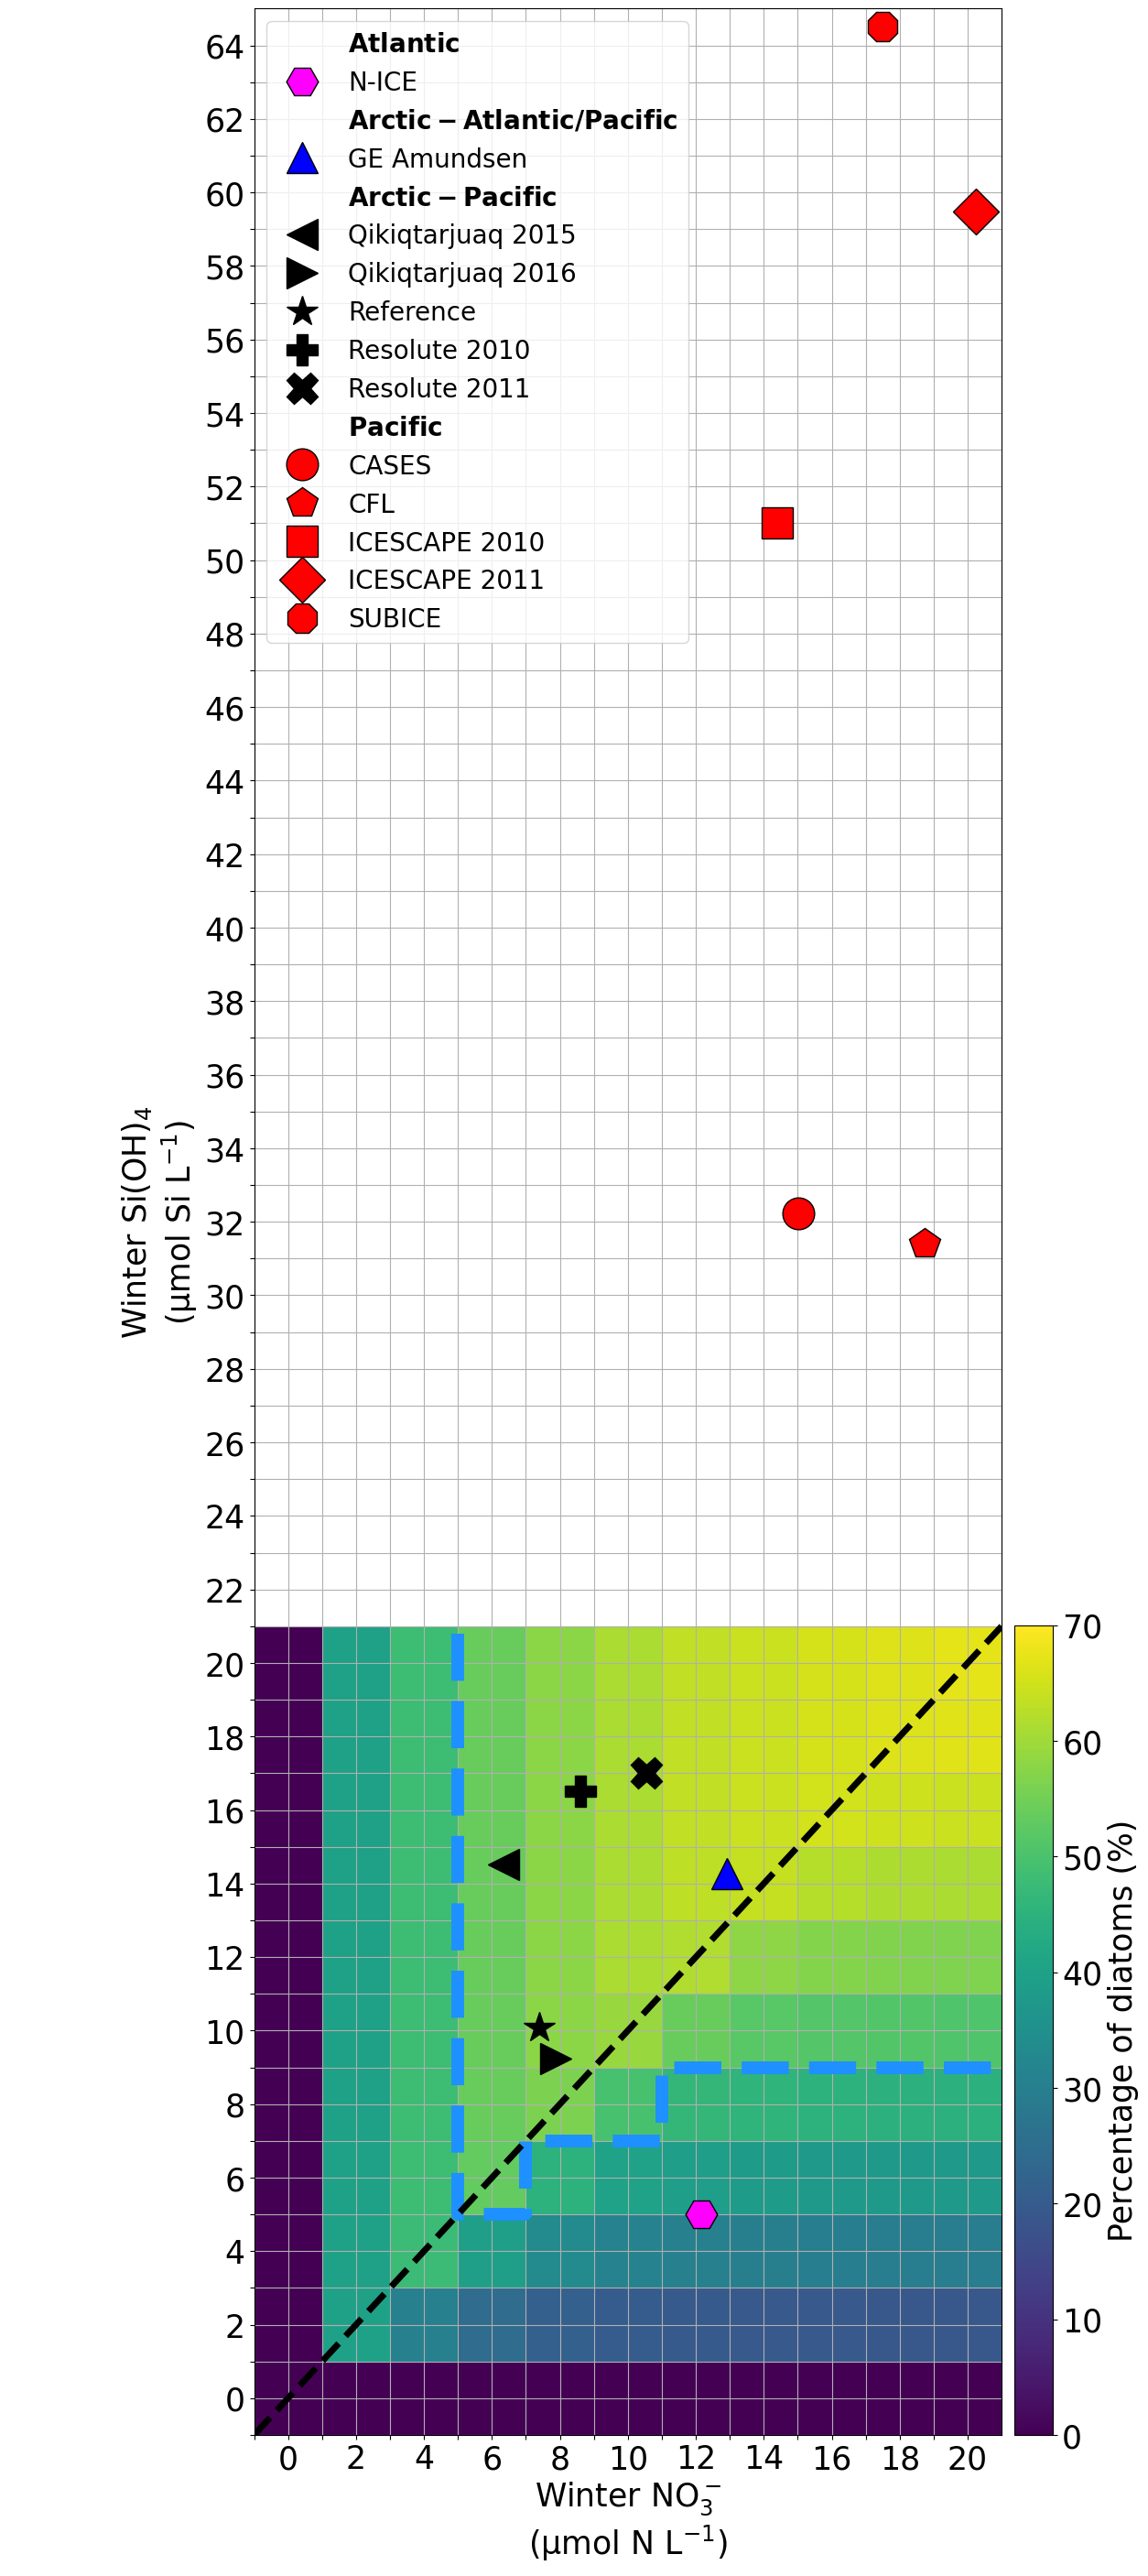

In [125]:
def make_plots(axs):
    
    # --- PERCENTAGE OF DIATOMS
    ax=axs[0]
    h=ax.pcolormesh(imeshno3,
                    imeshsi_high,
                    array2d_isi70_ino3_diatoms_perc,
                    cmap='viridis',
                    vmin=0,
                    vmax=70)
    ax.set_xticks(np.arange(-1,max_meshno3))
    ax.set_yticks(np.arange(-1,max_meshsi_high))
    xticklabels=[i if i%2==0 else '' for i in range(-1,max_meshno3)]
    yticklabels=[i if i%2==0 else '' for i in range(-1,max_meshsi_high)]
    ax.set_xticklabels(xticklabels)
    ax.set_yticklabels(yticklabels)
    ax.grid()
    ax.set_xlabel('Winter $\mathrm{ NO_3^- }$'
                  '\n($\mathrm{ \mu mol\ N\ L^{-1} }$)')
    ax.set_ylabel('Winter $\mathrm{ Si(OH)_4 }$'
                  '\n($\mathrm{ \mu mol\ Si\ L^{-1} }$)')
    cbaxes = fig.add_axes([0.78,0.05, 0.03,0.307])
    cbar=plt.colorbar(h,cax = cbaxes)
    cbar.set_label('Percentage of diatoms (%)')
    
    # enclose region where diatoms > 50%
    h=ax.plot(np.array(df_for_ardyna2020.x),
              np.array(df_for_ardyna2020.y),
              color='dodgerblue',linestyle='--')
    # diagonal
    ax.plot([-1,21],
            [-1,21],
            color='black',linestyle='--',linewidth=5)
#     # vertical
#     ax.axvline(5,
#                ymax=(21+1)/(imeshsi_high[-1]+1),
#                color='black',linestyle='--',linewidth=5)
    
    # --- 11 EXPEDITIONS
    for _,cruise in expeditions_df.iterrows():
        nitrate=cruise['Nitrate']
        silicate=cruise['Silicate']
        marker=cruise['Marker']
        label=cruise['Label']
        color=cruise['Color']
        alpha=cruise['Alpha']
        ax.plot(nitrate,silicate,
                color=color,marker=marker,alpha=alpha,label=label)
    ax.legend()
    
    # --- NOTHING
    ax=axs[1]
    ax.axis('off')
    
    # --- POSITION
    axs[0].set_position([0.19,0.05,0.58,0.92])
    axs[1].set_position([0.00,0.00,0.01,0.01])

with plt.style.context('mplstyles/ardyna2020.mplstyle'):
    fig,axs=plt.subplots(nrows=2,figsize=(14.08,28.80))
    make_plots(axs)
    outfile='figures/figure6.'+ext
    plt.savefig(outfile,dpi=dpi)